In [145]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from vizman import viz
import os
import pickle

import matplotlib.gridspec as gridspec

from scipy.cluster.hierarchy import linkage, leaves_list, fcluster
from scipy.spatial.distance import squareform

# Create a PCA between the columns of the huge_df
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from scipy.interpolate import make_smoothing_spline  # or UnivariateSpline
from matplotlib.collections import LineCollection

print(os.getcwd())  # Should show the project root 

from config import COLORS, COLOR_SCHEME, LABEL_MAP, gray_cmap, bone_white, half_black, emp_dataset_and_experiment_pairs
from config import CATEGORY_ORDER, CATEGORY_COLOURS # Integration etc.
import re
from config import PROPERTY_NAMES, remaining_categories, REPRESENTATIVES_FOR_GOALS, selected_properties

%load_ext autoreload
%autoreload 2

/Users/adrian/Documents/01_projects/14_4D_lab/connectome_distances/B_pca_and_pareto_trade-off
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [146]:
output_folder = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis")
output_folder.mkdir(exist_ok=True)


with open(output_folder / "all_datasets_precise_categories.pkl", "rb") as f:
    dict_with_all_datasets = pickle.load(f)
    

output_folder = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/01_lexi_ages")
output_folder.mkdir(exist_ok=True)


In [147]:
ordered_dataset_names = [# 'hcp_schaefer_100_dataset_gnm', 
                        # 'hcp_schaefer_100_dataset', 
                        # 'suarez_MaMI_dataset', 
                        'lexis_data_young', 
                        # 'lexis_data_aging',
                        # 'lexis_data_developing', 
                        # 'kaysons_generated_networks_diffusion', 
                        # 'kaysons_generated_networks_propagation', 
                        # 'kaysons_generated_networks_routing', 
                        # 'kaysons_generated_networks_topology', 
                        ]

In [148]:
huge_df = pd.DataFrame()

# combine all the metrics into one dataframe for this experiment
for dataset_name in ordered_dataset_names: 
    df = dict_with_all_datasets[dataset_name]
    # Add a column to identify the dataset
    df["dataset"] = dataset_name
    
    print(dataset_name, len(df))
    # Remove this, as eta, gamma, etc are not defined here? 
    if dataset_name == "kaysons_generated_networks_topology" or dataset_name == "hcp_schaefer_100_dataset": 
        print(" ---> skipped")
        continue
    huge_df = pd.concat([huge_df, df], ignore_index=True)

lexis_data_young 703


/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/01_lexi_ages/corr_matrix_categorised.pdf


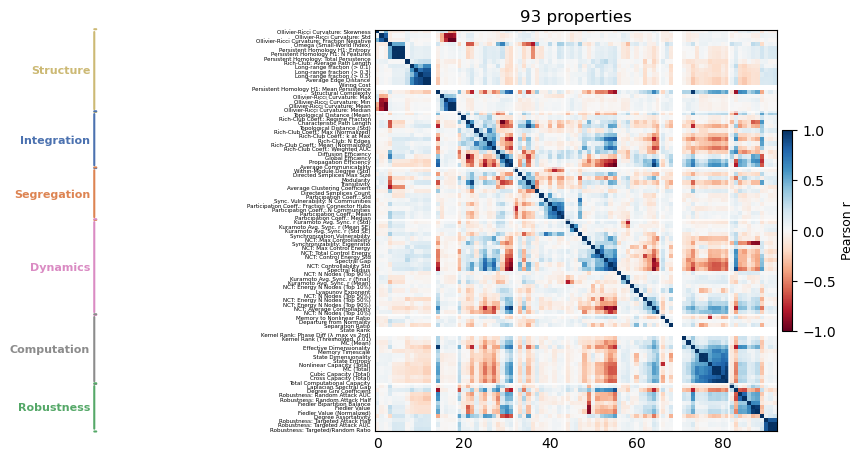

In [149]:


# For pca always drop the dataset column and only use the metric columns
huge_df_properties = huge_df.drop(columns=["dataset"]) # , "color_dataset"])

# Make a correlation axis between the columns of the huge_df. Don't use the dataset column for this, only the metric columns.
correlation_matrix = huge_df_properties.corr()

# ── 1. Load category / section metadata from Excel ────────────────────────────
excel_path = "/Users/adrian/Desktop/network_properties_full_excel.xlsx" # network_properties_full_excel.xlsx"   # ← adjust path if needed
meta_raw = pd.read_excel(excel_path, sheet_name=0)

meta_raw["section"] = meta_raw.apply(
    lambda r: r["#"] if pd.isna(r["Variable Name"]) and pd.notna(r["#"]) else None,
    axis=1,
).ffill()

meta = (
    meta_raw[meta_raw["Variable Name"].notna()]
    [["Variable Name", "Category", "section"]]
    .rename(columns={"Variable Name": "var"})
    .set_index("var")
)


# ── 2. Sort variables by category, then section ───────────────────────────────
cols_in_data = [c for c in huge_df_properties.columns if c in meta.index]

def sort_key(col):
    row = meta.loc[col]
    cat = row["Category"] if pd.notna(row["Category"]) else "ZZZ"
    cat_idx = CATEGORY_ORDER.index(cat) if cat in CATEGORY_ORDER else len(CATEGORY_ORDER)
    return (cat_idx, str(row["section"]))

cols_sorted_by_cat = sorted(cols_in_data, key=sort_key)

# ── 3. Within-category hierarchical clustering ────────────────────────────────
corr_full = huge_df_properties[cols_in_data].corr()

final_order = []
for cat in CATEGORY_ORDER:
    cat_cols = [c for c in cols_sorted_by_cat if meta.loc[c, "Category"] == cat]
    if len(cat_cols) == 0:
        continue
    if len(cat_cols) == 1:
        final_order.extend(cat_cols)
        continue
    sub_corr = corr_full.loc[cat_cols, cat_cols].fillna(0)
    dist = np.clip(1 - sub_corr.values, 0, 2)
    np.fill_diagonal(dist, 0)
    Z = linkage(squareform(dist, checks=False), method="average")
    final_order.extend([cat_cols[i] for i in leaves_list(Z)])

# Append any uncategorised variables at the end
final_order.extend([c for c in cols_in_data if c not in final_order])

# ── 4. Reorder & label ────────────────────────────────────────────────────────
reduced_corr = corr_full.loc[final_order, final_order]
new_labels = [PROPERTY_NAMES.get(c, c) for c in final_order]

# ── 5. Plot ───────────────────────────────────────────────────────────────────
n = len(final_order)
fig = plt.figure(figsize=viz.cm_to_inch((18,12)))

gs = gridspec.GridSpec(1, 1, left=0.22, right=0.97, top=0.97, bottom=0.12)
ax = fig.add_subplot(gs[0])

im = ax.imshow(
    reduced_corr.values,
    cmap="RdBu", vmin=-1, vmax=1,
    aspect="equal", 
    interpolation="none",
)

# White dividers between categories
boundaries, prev_cat = [0], meta.loc[final_order[0], "Category"]
for i, c in enumerate(final_order[1:], start=1):
    curr_cat = meta.loc[c, "Category"] if c in meta.index else None
    if curr_cat != prev_cat:
        boundaries.append(i)
        prev_cat = curr_cat
boundaries.append(n)

for b in boundaries[1:-1]:
    ax.axhline(b - 0.5, color="white", linewidth=1.2, alpha=0.85)
    ax.axvline(b - 0.5, color="white", linewidth=1.2, alpha=0.85)

# Tick labels
# ax.set_xticks(np.arange(n))
# ax.set_xticklabels(new_labels, rotation=90, fontsize=8, ha="right")
ax.set_yticks(np.arange(n))
ax.set_yticklabels(new_labels, fontsize=4)
ax.tick_params(axis="both", which="both", length=0)

# ── 6. Category brackets on the left ─────────────────────────────────────────
moving_stuff = -0.5
BRACKET_X = -0.20 + moving_stuff
SERIF_W   = 0.005 
LABEL_X   = -0.21 + moving_stuff
trans     = ax.transAxes

cat_row_spans = {}
for row_i, c in enumerate(final_order):
    cat = meta.loc[c, "Category"] if c in meta.index else "Other"
    cat_row_spans.setdefault(cat, [row_i, row_i])[1] = row_i

def row_to_y(row_i, n):
    return 1.0 - (row_i + 0.5) / n

for cat, (r0, r1) in cat_row_spans.items():
    colour  = CATEGORY_COLOURS.get(cat, "#444444")
    weird_adapter = 0.00085
    y_top   = row_to_y(r0, n) + 0.5 / n + weird_adapter
    y_bot   = row_to_y(r1, n) - 0.5 / n - weird_adapter
    y_mid   = (y_top + y_bot) / 2
    kw      = dict(xycoords=trans, textcoords=trans, annotation_clip=False,
                   arrowprops=dict(arrowstyle="-", color=colour, lw=1.5))

    ax.annotate("", xy=(BRACKET_X, y_bot),       xytext=(BRACKET_X, y_top),   **kw)  # vertical bar
    ax.annotate("", xy=(BRACKET_X, y_top),        xytext=(BRACKET_X+SERIF_W, y_top), **kw)  # top serif
    ax.annotate("", xy=(BRACKET_X, y_bot),        xytext=(BRACKET_X+SERIF_W, y_bot), **kw)  # bottom serif
    ax.text(LABEL_X, y_mid, cat, transform=trans,
            ha="right", va="center", fontsize=8, fontweight="bold",
            color=colour, clip_on=False)

cbar = fig.colorbar(im, ax=ax, shrink=0.5, pad=0.01)
cbar.set_label("Pearson r", fontsize=9)
ax.set_title(f"{n} properties", # Correlation Matrix - {n} metrics (ordered by category, clustered within)",
            #  fontsize=11, 
            #  pad=8
             )

plt.savefig(output_folder / "corr_matrix_categorised.pdf", dpi=150, bbox_inches="tight")
print(output_folder / "corr_matrix_categorised.pdf")
plt.show()

All-NaN correlation columns: ['kernel_rank_phase_diff_of_lambda_max_and_2nd', 'persistent_homology_ph_h1_persistence_mean', 'computational_capacity_state_rank']


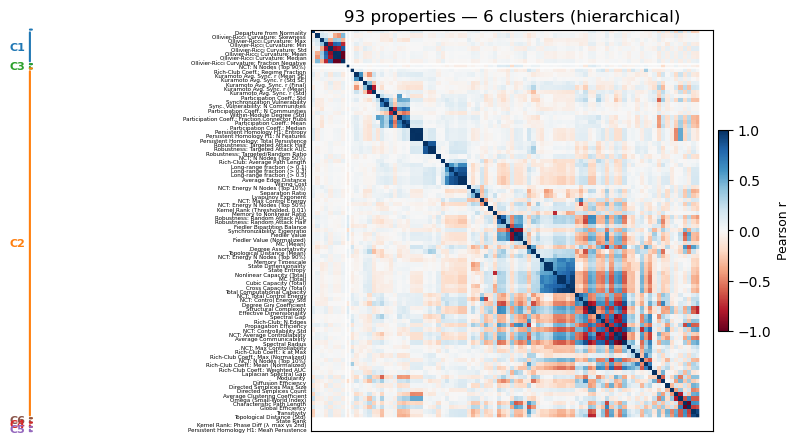


Cluster 1 (8 vars):
  Departure from Normality, Ollivier-Ricci Curvature: Skewness, Ollivier-Ricci Curvature: Max, Ollivier-Ricci Curvature: Min, Ollivier-Ricci Curvature: Std, Ollivier-Ricci Curvature: Mean, Ollivier-Ricci Curvature: Median, Ollivier-Ricci Curvature: Fraction Negative

Cluster 2 (81 vars):
  Rich-Club Coeff.: Regime Fraction, Kuramoto Avg. Sync. r (Mean SE), Kuramoto Avg. Sync. r (Std SE), Kuramoto Avg. Sync. r (Final), Kuramoto Avg. Sync. r (Mean), Kuramoto Avg. Sync. r (Std), Participation Coeff.: Std, Synchronization Vulnerability, Sync. Vulnerability: N Communities, Participation Coeff.: N Communities, Within-Module Degree (Std), Participation Coeff.: Fraction Connector Hubs, Participation Coeff.: Mean, Participation Coeff.: Median, Persistent Homology H1: Entropy, Persistent Homology H1: N Features, Persistent Homology: Total Persistence, Robustness: Targeted Attack Half, Robustness: Targeted Attack AUC, Robustness: Targeted/Random Ratio, NCT: N Nodes (Top 50%),

In [150]:

# ── 1. Full-matrix hierarchical clustering ────────────────────────────────────
cols_in_data = [c for c in huge_df_properties.columns if c in meta.index]
# corr_full    = huge_df_properties[cols_in_data].corr()

corr_full = huge_df_properties[cols_in_data].corr()

nan_cols = corr_full.columns[corr_full.isna().all()].tolist()
print(f"All-NaN correlation columns: {nan_cols}")

# Fill NaNs before computing distance (NaN arises from constant or collinear columns)
corr_clean = corr_full.fillna(0)  # treat unknown correlation as uncorrelated

# dist = np.clip(1 - np.abs(corr_clean.values), 0, 1)
dist = np.clip(1 - np.abs(corr_clean.values), 0, 1)  # was: 1 - corr_full.values

np.fill_diagonal(dist, 0)
Z = linkage(squareform(dist, checks=False), method="average")

final_order  = [cols_in_data[i] for i in leaves_list(Z)]
reduced_corr = corr_full.loc[final_order, final_order]
new_labels   = [PROPERTY_NAMES.get(c, c) for c in final_order]

# ── 2. Cut the dendrogram into N clusters & assign colours ───────────────────
N_CLUSTERS = 6  # ← tune this
cluster_ids = fcluster(Z, N_CLUSTERS, criterion="maxclust")
# fcluster returns ids in original column order, remap to final_order
orig_to_cluster = dict(zip(cols_in_data, cluster_ids))

cluster_palette = plt.cm.tab10.colors
def cluster_colour(col):
    cid = orig_to_cluster.get(col, 0)
    return cluster_palette[(cid - 1) % len(cluster_palette)]

# ── 3. Plot ───────────────────────────────────────────────────────────────────
n   = len(final_order)
fig = plt.figure(figsize=viz.cm_to_inch((18, 12)))
gs  = gridspec.GridSpec(1, 1, left=0.22, right=0.97, top=0.97, bottom=0.12)
ax  = fig.add_subplot(gs[0])

im = ax.imshow(
    reduced_corr.values,
    cmap="RdBu", vmin=-1, vmax=1,
    aspect="equal", interpolation="none",
)

# ── 4. White dividers between clusters ───────────────────────────────────────
prev_c = orig_to_cluster[final_order[0]]
for i, col in enumerate(final_order[1:], start=1):
    if orig_to_cluster[col] != prev_c:
        ax.axhline(i - 0.5, color="white", linewidth=1.2, alpha=0.85)
        ax.axvline(i - 0.5, color="white", linewidth=1.2, alpha=0.85)
    prev_c = orig_to_cluster[col]

# ── 5. Tick labels ────────────────────────────────────────────────────────────
ax.set_yticks(np.arange(n)) 
ax.set_yticklabels(new_labels, fontsize=4)
ax.set_xticks([])
ax.tick_params(axis="both", which="both", length=0)

# ── 6. Cluster brackets on the left ──────────────────────────────────────────
moving_stuff = -0.5
BRACKET_X = -0.20 + moving_stuff
SERIF_W   =  0.005
LABEL_X   = -0.21 + moving_stuff
trans     = ax.transAxes

# Build row spans per cluster (in display order)
cluster_row_spans = {}
for row_i, col in enumerate(final_order):
    cid = orig_to_cluster[col]
    cluster_row_spans.setdefault(cid, [row_i, row_i])[1] = row_i

def row_to_y(row_i, n):
    return 1.0 - (row_i + 0.5) / n

for cid, (r0, r1) in cluster_row_spans.items():
    colour = cluster_palette[(cid - 1) % len(cluster_palette)]
    y_top  = row_to_y(r0, n) + 0.5 / n
    y_bot  = row_to_y(r1, n) - 0.5 / n
    y_mid  = (y_top + y_bot) / 2
    kw     = dict(xycoords=trans, textcoords=trans, annotation_clip=False,
                  arrowprops=dict(arrowstyle="-", color=colour, lw=1.5))

    ax.annotate("", xy=(BRACKET_X, y_bot),            xytext=(BRACKET_X, y_top),            **kw)
    ax.annotate("", xy=(BRACKET_X, y_top),             xytext=(BRACKET_X + SERIF_W, y_top),  **kw)
    ax.annotate("", xy=(BRACKET_X, y_bot),             xytext=(BRACKET_X + SERIF_W, y_bot),  **kw)
    ax.text(LABEL_X, y_mid, f"C{cid}", transform=trans,
            ha="right", va="center", fontsize=8, fontweight="bold",
            color=colour, clip_on=False)

cbar = fig.colorbar(im, ax=ax, shrink=0.5, pad=0.01)
cbar.set_label("Pearson r", fontsize=9)
ax.set_title(f"{n} properties — {N_CLUSTERS} clusters (hierarchical)")

plt.savefig(output_folder / "corr_matrix_clustered.pdf", dpi=150, bbox_inches="tight")
plt.show()

# ── 7. Print cluster compositions ─────────────────────────────────────────────
for cid in sorted(cluster_row_spans):
    members = [PROPERTY_NAMES.get(c, c) for c in final_order
               if orig_to_cluster[c] == cid]
    print(f"\nCluster {cid} ({len(members)} vars):")
    print("  " + ", ".join(members))

In [151]:


precise_categories = []
for cat_name, cat_cols in remaining_categories.items(): 
    
    for col in cat_cols:
        precise_categories.append(col)


# precise_categories
len(precise_categories)

31

In [152]:

# --- Config ---
THRESHOLD = 0.95  # only flag pairs above this

# Start fresh each run from the full metric set
remaining_cols = huge_df_properties.columns.tolist()
print(len(remaining_cols), "columns before removals")
# remove all columns that are not in PROPERTY_NAMES.keys(): 
remaining_cols = [c for c in remaining_cols if c in precise_categories] # PROPERTY_NAMES.keys()]
print(len(remaining_cols), "columns after removing those not in 'precise_categories'")

to_remove = [
            # "char_path_length",
            ] 

if to_remove is not None:
    remaining_cols = [c for c in remaining_cols if c not in to_remove]


# ── Run this cell repeatedly ──────────────────────────────────────────────────
working_df = huge_df_properties[remaining_cols].copy()
corr = working_df.corr().abs()

# Zero out diagonal and lower triangle to avoid duplicates
mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
corr_upper = corr.where(mask)

# Find the single highest correlation
max_corr = corr_upper.stack().max()
max_pair = corr_upper.stack().idxmax()

if max_corr < THRESHOLD:
    print(f"✅ No correlations above {THRESHOLD}. Done! {len(remaining_cols)} variables remain.")
    print(f"Removed so far: {to_remove}")
else:
    var_a, var_b = max_pair
    print(f"⚠️  Highest correlation: {max_corr:.4f}")
    print(f"   → '{var_a}'")
    print(f"   → '{var_b}'")
    print()
    
    # Show each variable's mean absolute correlation with everything else
    # (helps you decide which is more redundant)
    mean_corr_a = corr_upper[var_a].fillna(corr_upper.T[var_a]).mean()
    mean_corr_b = corr_upper[var_b].fillna(corr_upper.T[var_b]).mean()
    print(f"   Mean |corr| with others:  '{var_a}' = {mean_corr_a:.3f}  |  '{var_b}' = {mean_corr_b:.3f}")
    print(f"   (Higher mean → more redundant overall → better candidate to drop)")
    print()
    # print("👉 Add one to `to_remove`, then re-run this cell:")
    # print(f"   to_remove.append('{var_a}')   # or '{var_b}'")

# # Apply removals
# remaining_cols = [c for c in huge_df_metrics.columns if c not in to_remove]
print(f"\n🗑️  Removed so far ({len(to_remove)}): {to_remove}")
print(f"📊 Remaining variables: {len(remaining_cols)}")

97 columns before removals
31 columns after removing those not in 'precise_categories'
⚠️  Highest correlation: 0.9902
   → 'targeted_attack_robustness_rob_targeted_auc'
   → 'targeted_attack_robustness_rob_ratio'

   Mean |corr| with others:  'targeted_attack_robustness_rob_targeted_auc' = 0.096  |  'targeted_attack_robustness_rob_ratio' = 0.081
   (Higher mean → more redundant overall → better candidate to drop)


🗑️  Removed so far (0): []
📊 Remaining variables: 31


In [153]:
# Apply the selection
huge_df_properties = huge_df_properties[remaining_cols]

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/01_lexi_ages/corr_matrix_categorised.pdf


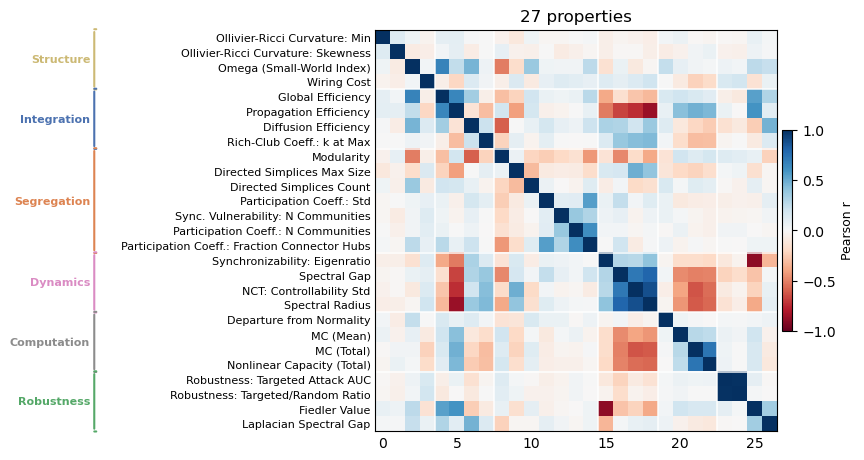

In [154]:


# ── 1. Load category / section metadata from Excel ────────────────────────────
excel_path = "/Users/adrian/Desktop/network_properties_full_excel.xlsx" # network_properties_full_excel.xlsx"   # ← adjust path if needed
meta_raw = pd.read_excel(excel_path, sheet_name=0)

meta_raw["section"] = meta_raw.apply(
    lambda r: r["#"] if pd.isna(r["Variable Name"]) and pd.notna(r["#"]) else None,
    axis=1,
).ffill()

meta = (
    meta_raw[meta_raw["Variable Name"].notna()]
    [["Variable Name", "Category", "section"]]
    .rename(columns={"Variable Name": "var"})
    .set_index("var")
)



# ── 2. Sort variables by category, then section ───────────────────────────────
cols_in_data = [c for c in huge_df_properties.columns if c in meta.index]

def sort_key(col):
    row = meta.loc[col]
    cat = row["Category"] if pd.notna(row["Category"]) else "ZZZ"
    cat_idx = CATEGORY_ORDER.index(cat) if cat in CATEGORY_ORDER else len(CATEGORY_ORDER)
    return (cat_idx, str(row["section"]))

cols_sorted_by_cat = sorted(cols_in_data, key=sort_key)

# ── 3. Within-category hierarchical clustering ────────────────────────────────
corr_full = huge_df_properties[cols_in_data].corr()

final_order = []
for cat in CATEGORY_ORDER:
    cat_cols = [c for c in cols_sorted_by_cat if meta.loc[c, "Category"] == cat]
    if len(cat_cols) == 0:
        continue
    if len(cat_cols) == 1:
        final_order.extend(cat_cols)
        continue
    sub_corr = corr_full.loc[cat_cols, cat_cols].fillna(0)
    dist = np.clip(1 - sub_corr.values, 0, 2)
    np.fill_diagonal(dist, 0)
    Z = linkage(squareform(dist, checks=False), method="average")
    final_order.extend([cat_cols[i] for i in leaves_list(Z)])

# Append any uncategorised variables at the end
final_order.extend([c for c in cols_in_data if c not in final_order])

# ── 4. Reorder & label ────────────────────────────────────────────────────────
reduced_corr = corr_full.loc[final_order, final_order]
new_labels = [PROPERTY_NAMES.get(c, c) for c in final_order]

# ── 5. Plot ───────────────────────────────────────────────────────────────────
n = len(final_order)
fig = plt.figure(figsize=viz.cm_to_inch((18,12)))

gs = gridspec.GridSpec(1, 1, left=0.22, right=0.97, top=0.97, bottom=0.12)
ax = fig.add_subplot(gs[0])

im = ax.imshow(
    reduced_corr.values,
    cmap="RdBu", vmin=-1, vmax=1,
    aspect="equal", 
    interpolation="none",
)

# White dividers between categories
boundaries, prev_cat = [0], meta.loc[final_order[0], "Category"]
for i, c in enumerate(final_order[1:], start=1):
    curr_cat = meta.loc[c, "Category"] if c in meta.index else None
    if curr_cat != prev_cat:
        boundaries.append(i)
        prev_cat = curr_cat
boundaries.append(n)

for b in boundaries[1:-1]:
    ax.axhline(b - 0.5, color="white", linewidth=1.2, alpha=0.85)
    ax.axvline(b - 0.5, color="white", linewidth=1.2, alpha=0.85)

# Tick labels
# ax.set_xticks(np.arange(n))
# ax.set_xticklabels(new_labels, rotation=90, fontsize=8, ha="right")
ax.set_yticks(np.arange(n))
ax.set_yticklabels(new_labels, fontsize=8)
ax.tick_params(axis="both", which="both", length=0)

# ── 6. Category brackets on the left ─────────────────────────────────────────
moving_stuff = -0.5
BRACKET_X = -0.20 + moving_stuff
SERIF_W   = 0.005 
LABEL_X   = -0.21 + moving_stuff
trans     = ax.transAxes

cat_row_spans = {}
for row_i, c in enumerate(final_order):
    cat = meta.loc[c, "Category"] if c in meta.index else "Other"
    cat_row_spans.setdefault(cat, [row_i, row_i])[1] = row_i

def row_to_y(row_i, n):
    return 1.0 - (row_i + 0.5) / n

for cat, (r0, r1) in cat_row_spans.items():
    colour  = CATEGORY_COLOURS.get(cat, "#444444")
    weird_adapter = 0.00085
    y_top   = row_to_y(r0, n) + 0.5 / n + weird_adapter
    y_bot   = row_to_y(r1, n) - 0.5 / n - weird_adapter
    y_mid   = (y_top + y_bot) / 2
    kw      = dict(xycoords=trans, textcoords=trans, annotation_clip=False,
                   arrowprops=dict(arrowstyle="-", color=colour, lw=1.5))

    ax.annotate("", xy=(BRACKET_X, y_bot),       xytext=(BRACKET_X, y_top),   **kw)  # vertical bar
    ax.annotate("", xy=(BRACKET_X, y_top),        xytext=(BRACKET_X+SERIF_W, y_top), **kw)  # top serif
    ax.annotate("", xy=(BRACKET_X, y_bot),        xytext=(BRACKET_X+SERIF_W, y_bot), **kw)  # bottom serif
    ax.text(LABEL_X, y_mid, cat, transform=trans,
            ha="right", va="center", fontsize=8, fontweight="bold",
            color=colour, clip_on=False)

cbar = fig.colorbar(im, ax=ax, shrink=0.5, pad=0.01)
cbar.set_label("Pearson r", fontsize=9)
ax.set_title(f"{n} properties", # Correlation Matrix - {n} metrics (ordered by category, clustered within)",
            #  fontsize=11, 
            #  pad=8
             )

plt.savefig(output_folder / "corr_matrix_categorised.pdf", dpi=150, bbox_inches="tight")
print(output_folder / "corr_matrix_categorised.pdf")
plt.show()

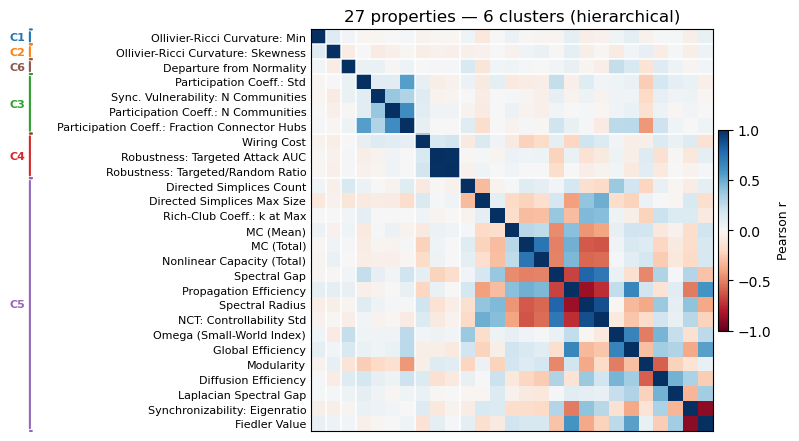


Cluster 1 (1 vars):
  Ollivier-Ricci Curvature: Min

Cluster 2 (1 vars):
  Ollivier-Ricci Curvature: Skewness

Cluster 3 (4 vars):
  Participation Coeff.: Std, Sync. Vulnerability: N Communities, Participation Coeff.: N Communities, Participation Coeff.: Fraction Connector Hubs

Cluster 4 (3 vars):
  Wiring Cost, Robustness: Targeted Attack AUC, Robustness: Targeted/Random Ratio

Cluster 5 (17 vars):
  Directed Simplices Count, Directed Simplices Max Size, Rich-Club Coeff.: k at Max, MC (Mean), MC (Total), Nonlinear Capacity (Total), Spectral Gap, Propagation Efficiency, Spectral Radius, NCT: Controllability Std, Omega (Small-World Index), Global Efficiency, Modularity, Diffusion Efficiency, Laplacian Spectral Gap, Synchronizability: Eigenratio, Fiedler Value

Cluster 6 (1 vars):
  Departure from Normality


In [155]:


# ── 1. Full-matrix hierarchical clustering ────────────────────────────────────
cols_in_data = [c for c in huge_df_properties.columns if c in meta.index]
corr_full    = huge_df_properties[cols_in_data].corr()

# dist = np.clip(1 - corr_full.values, 0, 2)
dist = np.clip(1 - np.abs(corr_full.values), 0, 1)  # was: 1 - corr_full.values

np.fill_diagonal(dist, 0)
Z = linkage(squareform(dist, checks=False), method="average")

final_order  = [cols_in_data[i] for i in leaves_list(Z)]
reduced_corr = corr_full.loc[final_order, final_order]
new_labels   = [PROPERTY_NAMES.get(c, c) for c in final_order]

# ── 2. Cut the dendrogram into N clusters & assign colours ───────────────────
N_CLUSTERS = 6  # ← tune this
cluster_ids = fcluster(Z, N_CLUSTERS, criterion="maxclust")
# fcluster returns ids in original column order, remap to final_order
orig_to_cluster = dict(zip(cols_in_data, cluster_ids))

cluster_palette = plt.cm.tab10.colors
def cluster_colour(col):
    cid = orig_to_cluster.get(col, 0)
    return cluster_palette[(cid - 1) % len(cluster_palette)]

# ── 3. Plot ───────────────────────────────────────────────────────────────────
n   = len(final_order)
fig = plt.figure(figsize=viz.cm_to_inch((18, 12)))
gs  = gridspec.GridSpec(1, 1, left=0.22, right=0.97, top=0.97, bottom=0.12)
ax  = fig.add_subplot(gs[0])

im = ax.imshow(
    reduced_corr.values,
    cmap="RdBu", vmin=-1, vmax=1,
    aspect="equal", interpolation="none",
)

# ── 4. White dividers between clusters ───────────────────────────────────────
prev_c = orig_to_cluster[final_order[0]]
for i, col in enumerate(final_order[1:], start=1):
    if orig_to_cluster[col] != prev_c:
        ax.axhline(i - 0.5, color="white", linewidth=1.2, alpha=0.85)
        ax.axvline(i - 0.5, color="white", linewidth=1.2, alpha=0.85)
    prev_c = orig_to_cluster[col]

# ── 5. Tick labels ────────────────────────────────────────────────────────────
ax.set_yticks(np.arange(n))
ax.set_yticklabels(new_labels, fontsize=8)
ax.set_xticks([])
ax.tick_params(axis="both", which="both", length=0)

# ── 6. Cluster brackets on the left ──────────────────────────────────────────
moving_stuff = -0.5
BRACKET_X = -0.20 + moving_stuff
SERIF_W   =  0.005
LABEL_X   = -0.21 + moving_stuff
trans     = ax.transAxes

# Build row spans per cluster (in display order)
cluster_row_spans = {}
for row_i, col in enumerate(final_order):
    cid = orig_to_cluster[col]
    cluster_row_spans.setdefault(cid, [row_i, row_i])[1] = row_i

def row_to_y(row_i, n):
    return 1.0 - (row_i + 0.5) / n

for cid, (r0, r1) in cluster_row_spans.items():
    colour = cluster_palette[(cid - 1) % len(cluster_palette)]
    y_top  = row_to_y(r0, n) + 0.5 / n
    y_bot  = row_to_y(r1, n) - 0.5 / n
    y_mid  = (y_top + y_bot) / 2
    kw     = dict(xycoords=trans, textcoords=trans, annotation_clip=False,
                  arrowprops=dict(arrowstyle="-", color=colour, lw=1.5))

    ax.annotate("", xy=(BRACKET_X, y_bot),            xytext=(BRACKET_X, y_top),            **kw)
    ax.annotate("", xy=(BRACKET_X, y_top),             xytext=(BRACKET_X + SERIF_W, y_top),  **kw)
    ax.annotate("", xy=(BRACKET_X, y_bot),             xytext=(BRACKET_X + SERIF_W, y_bot),  **kw)
    ax.text(LABEL_X, y_mid, f"C{cid}", transform=trans,
            ha="right", va="center", fontsize=8, fontweight="bold",
            color=colour, clip_on=False)

cbar = fig.colorbar(im, ax=ax, shrink=0.5, pad=0.01)
cbar.set_label("Pearson r", fontsize=9)
ax.set_title(f"{n} properties — {N_CLUSTERS} clusters (hierarchical)")

plt.savefig(output_folder / "corr_matrix_clustered.pdf", dpi=150, bbox_inches="tight")
plt.show()

# ── 7. Print cluster compositions ─────────────────────────────────────────────
for cid in sorted(cluster_row_spans):
    members = [PROPERTY_NAMES.get(c, c) for c in final_order
               if orig_to_cluster[c] == cid]
    print(f"\nCluster {cid} ({len(members)} vars):")
    print("  " + ", ".join(members))

In [156]:
huge_df_properties.columns 

Index(['modularity', 'omega', 'directed_simplices_count',
       'directed_simplices_max_size', 'global_efficiency',
       'diffusion_efficiency', 'propagation_efficiency', 'wiring_cost',
       'proportion_long_range_connections_0.3956',
       'rich_club_coefficient_rc_k_at_max', 'spectral_radius', 'spectral_gap',
       'synchronizability_eigenratio_eigenratio',
       'algebraic_connectivity_fiedler_value',
       'algebraic_connectivity_laplacian_spectral_gap',
       'departure_from_normality_schur',
       'repertoire_sweep_weighted_by_distances_T_critical',
       'repertoire_sweep_weighted_by_distances_size_critical',
       'repertoire_sweep_weighted_by_distances_diversity_critical',
       'participation_coefficient_n_communities',
       'participation_coefficient_pc_std',
       'participation_coefficient_pc_frac_connector',
       'ollivier_ricci_curvature_orc_min',
       'ollivier_ricci_curvature_orc_skewness',
       'targeted_attack_robustness_rob_targeted_auc',
    

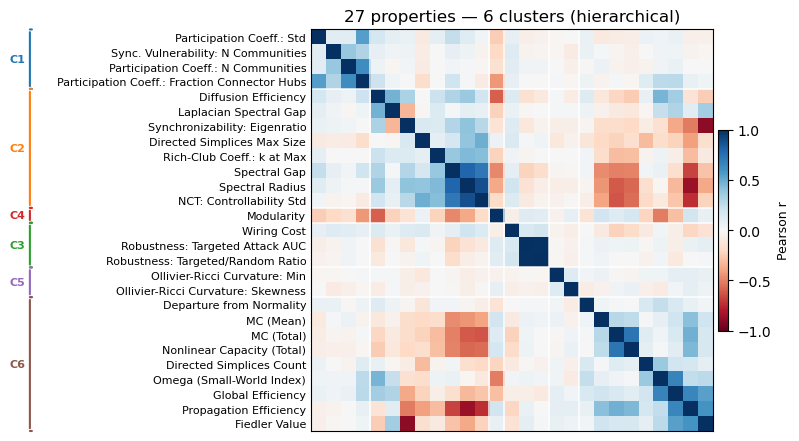


Cluster 1 (4 vars):
  Participation Coeff.: Std, Sync. Vulnerability: N Communities, Participation Coeff.: N Communities, Participation Coeff.: Fraction Connector Hubs

Cluster 2 (8 vars):
  Diffusion Efficiency, Laplacian Spectral Gap, Synchronizability: Eigenratio, Directed Simplices Max Size, Rich-Club Coeff.: k at Max, Spectral Gap, Spectral Radius, NCT: Controllability Std

Cluster 3 (3 vars):
  Wiring Cost, Robustness: Targeted Attack AUC, Robustness: Targeted/Random Ratio

Cluster 4 (1 vars):
  Modularity

Cluster 5 (2 vars):
  Ollivier-Ricci Curvature: Min, Ollivier-Ricci Curvature: Skewness

Cluster 6 (9 vars):
  Departure from Normality, MC (Mean), MC (Total), Nonlinear Capacity (Total), Directed Simplices Count, Omega (Small-World Index), Global Efficiency, Propagation Efficiency, Fiedler Value


In [157]:


# ── 1. Full-matrix hierarchical clustering ────────────────────────────────────
cols_in_data = [c for c in huge_df_properties.columns if c in meta.index]
corr_full    = huge_df_properties[cols_in_data].corr()

# Fill NaNs before computing distance (NaN arises from constant or collinear columns)
corr_clean = corr_full.fillna(0)  # treat unknown correlation as uncorrelated

dist = np.clip(1 - corr_clean.values, 0, 2)
np.fill_diagonal(dist, 0)
Z = linkage(squareform(dist, checks=False), method="average")

final_order  = [cols_in_data[i] for i in leaves_list(Z)]
reduced_corr = corr_full.loc[final_order, final_order]
new_labels   = [PROPERTY_NAMES.get(c, c) for c in final_order]

# ── 2. Cut the dendrogram into N clusters & assign colours ───────────────────
N_CLUSTERS = 6  # ← tune this
cluster_ids = fcluster(Z, N_CLUSTERS, criterion="maxclust")
# fcluster returns ids in original column order, remap to final_order
orig_to_cluster = dict(zip(cols_in_data, cluster_ids))

cluster_palette = plt.cm.tab10.colors
def cluster_colour(col):
    cid = orig_to_cluster.get(col, 0)
    return cluster_palette[(cid - 1) % len(cluster_palette)]

# ── 3. Plot ───────────────────────────────────────────────────────────────────
n   = len(final_order)
fig = plt.figure(figsize=viz.cm_to_inch((18, 12)))
gs  = gridspec.GridSpec(1, 1, left=0.22, right=0.97, top=0.97, bottom=0.12)
ax  = fig.add_subplot(gs[0])

im = ax.imshow(
    reduced_corr.values,
    cmap="RdBu", vmin=-1, vmax=1,
    aspect="equal", interpolation="none",
)

# ── 4. White dividers between clusters ───────────────────────────────────────
prev_c = orig_to_cluster[final_order[0]]
for i, col in enumerate(final_order[1:], start=1):
    if orig_to_cluster[col] != prev_c:
        ax.axhline(i - 0.5, color="white", linewidth=1.2, alpha=0.85)
        ax.axvline(i - 0.5, color="white", linewidth=1.2, alpha=0.85)
    prev_c = orig_to_cluster[col]

# ── 5. Tick labels ────────────────────────────────────────────────────────────
ax.set_yticks(np.arange(n))
ax.set_yticklabels(new_labels, fontsize=8)
ax.set_xticks([])
ax.tick_params(axis="both", which="both", length=0)

# ── 6. Cluster brackets on the left ──────────────────────────────────────────
moving_stuff = -0.5
BRACKET_X = -0.20 + moving_stuff
SERIF_W   =  0.005
LABEL_X   = -0.21 + moving_stuff
trans     = ax.transAxes

# Build row spans per cluster (in display order)
cluster_row_spans = {}
for row_i, col in enumerate(final_order):
    cid = orig_to_cluster[col]
    cluster_row_spans.setdefault(cid, [row_i, row_i])[1] = row_i

def row_to_y(row_i, n):
    return 1.0 - (row_i + 0.5) / n

for cid, (r0, r1) in cluster_row_spans.items():
    colour = cluster_palette[(cid - 1) % len(cluster_palette)]
    y_top  = row_to_y(r0, n) + 0.5 / n
    y_bot  = row_to_y(r1, n) - 0.5 / n
    y_mid  = (y_top + y_bot) / 2
    kw     = dict(xycoords=trans, textcoords=trans, annotation_clip=False,
                  arrowprops=dict(arrowstyle="-", color=colour, lw=1.5))

    ax.annotate("", xy=(BRACKET_X, y_bot),            xytext=(BRACKET_X, y_top),            **kw)
    ax.annotate("", xy=(BRACKET_X, y_top),             xytext=(BRACKET_X + SERIF_W, y_top),  **kw)
    ax.annotate("", xy=(BRACKET_X, y_bot),             xytext=(BRACKET_X + SERIF_W, y_bot),  **kw)
    ax.text(LABEL_X, y_mid, f"C{cid}", transform=trans,
            ha="right", va="center", fontsize=8, fontweight="bold",
            color=colour, clip_on=False)

cbar = fig.colorbar(im, ax=ax, shrink=0.5, pad=0.01)
cbar.set_label("Pearson r", fontsize=9)
ax.set_title(f"{n} properties — {N_CLUSTERS} clusters (hierarchical)")

plt.savefig(output_folder / "corr_matrix_clustered.pdf", dpi=150, bbox_inches="tight")
plt.show()

# ── 7. Print cluster compositions ─────────────────────────────────────────────
for cid in sorted(cluster_row_spans):
    members = [PROPERTY_NAMES.get(c, c) for c in final_order
               if orig_to_cluster[c] == cid]
    print(f"\nCluster {cid} ({len(members)} vars):")
    print("  " + ", ".join(members))

In [158]:
huge_df["color_dataset"] = [COLOR_SCHEME[d] for d in huge_df["dataset"]]

Dropped columns: []


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_58056/910796351.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


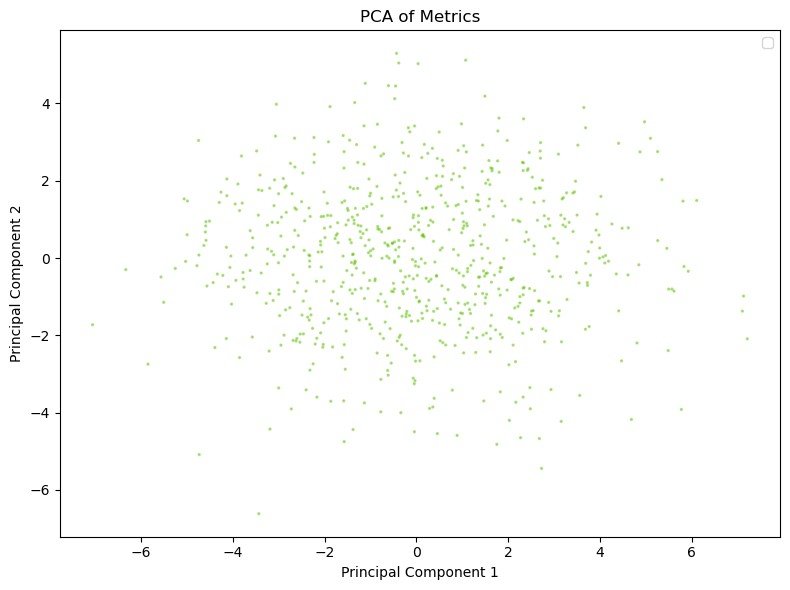

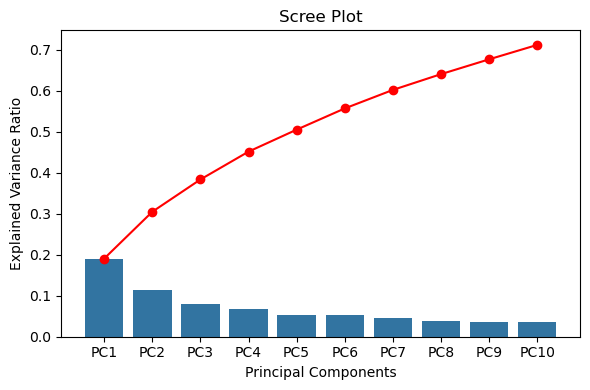

In [159]:

# Drop the columns that have inf or -inf values (if any). Print the dropped columns
dropped_cols = huge_df_properties.columns[huge_df_properties.isnull().any()].tolist()
huge_df_properties.replace([np.inf, -np.inf], np.nan, inplace=True)
huge_df_properties.dropna(axis=1, inplace=True)
print(f"Dropped columns: {dropped_cols}")

scaler = StandardScaler()
scaled_data = scaler.fit_transform(huge_df_properties)

pca = PCA(n_components=10) # 10)
pca_result = pca.fit_transform(scaled_data)

plt.figure(figsize=(8,6))
plt.scatter(x=pca_result[:,0], 
            y=pca_result[:,1], 
            s=2, 
            alpha=0.4, 
            c=huge_df['color_dataset'], 
            # label=huge_df['dataset']
        )
plt.title("PCA of Metrics")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.show()

# Scree plot to show explained variance
explained_variance = pca.explained_variance_ratio_
plt.figure(figsize=(6,4))
sns.barplot(x=[f"PC{i+1}" for i in range(len(explained_variance))], y=explained_variance)
plt.plot(range(0, len(explained_variance)), np.cumsum(explained_variance), marker="o", color="red",
        label="Cumulative")
plt.title("Scree Plot")
plt.ylabel("Explained Variance Ratio")
plt.xlabel("Principal Components")
plt.tight_layout()
plt.show()

In [160]:
# Subplots of loadings for the first 3 principal components, ONLY top 10 contributors
loadings = pca.components_.T
num_metrics = loadings.shape[0]
metric_names = huge_df_properties.columns

# order them all by the absolute value of their loading on the first principal component
sorted_indices = np.argsort((loadings[:, 0]))[::-1]
# sorted_indices = np.argsort(np.abs(loadings[:, 0]) + np.abs(loadings[:, 1]))[::-1]
abs_ordered_loadings = np.abs(loadings[sorted_indices, 0])
loadings = loadings[sorted_indices]
metric_names = metric_names[sorted_indices]

print("Top 30 contributors to PC1:")
for i in range(30):
    print(f"     {metric_names[i]}          {abs_ordered_loadings[i]}") # : {loadings[i, 0]:.4f}")

Top 30 contributors to PC1:
     spectral_radius          0.3845289351483377
     nct_control_std          0.34679922243456757
     spectral_gap          0.32879751773738225
     synchronizability_eigenratio_eigenratio          0.23121819736187338
     rich_club_coefficient_rc_k_at_max          0.18742163545424645
     directed_simplices_max_size          0.1749902158515752
     diffusion_efficiency          0.14828414291657963
     wiring_cost          0.1164789806615469
     proportion_long_range_connections_0.3956          0.0722429612584965
     participation_coefficient_pc_std          0.06592531457739749
     repertoire_sweep_weighted_by_distances_size_critical          0.04684486199066938
     repertoire_sweep_weighted_by_distances_diversity_critical          0.044261564817728576
     community_synchronization_vulnerability_n_communities          0.030693662646758952
     participation_coefficient_n_communities          0.01850027493923956
     participation_coefficient_pc_frac_

In [161]:
# # SPIDERS 

# "global_efficiency"       
# "algebraic_connectivity_fiedler_value"  
# "targeted_attack_robustness_rob_targeted_auc" 
# "proportion_long_range_connections_0.3956" 
# "mc_mean"
# "mc_nonlin_mean"
# "repertoire_sweep_weighted_by_distances_diversity_critical"
# "spectral_radius"        
# "modularity"         

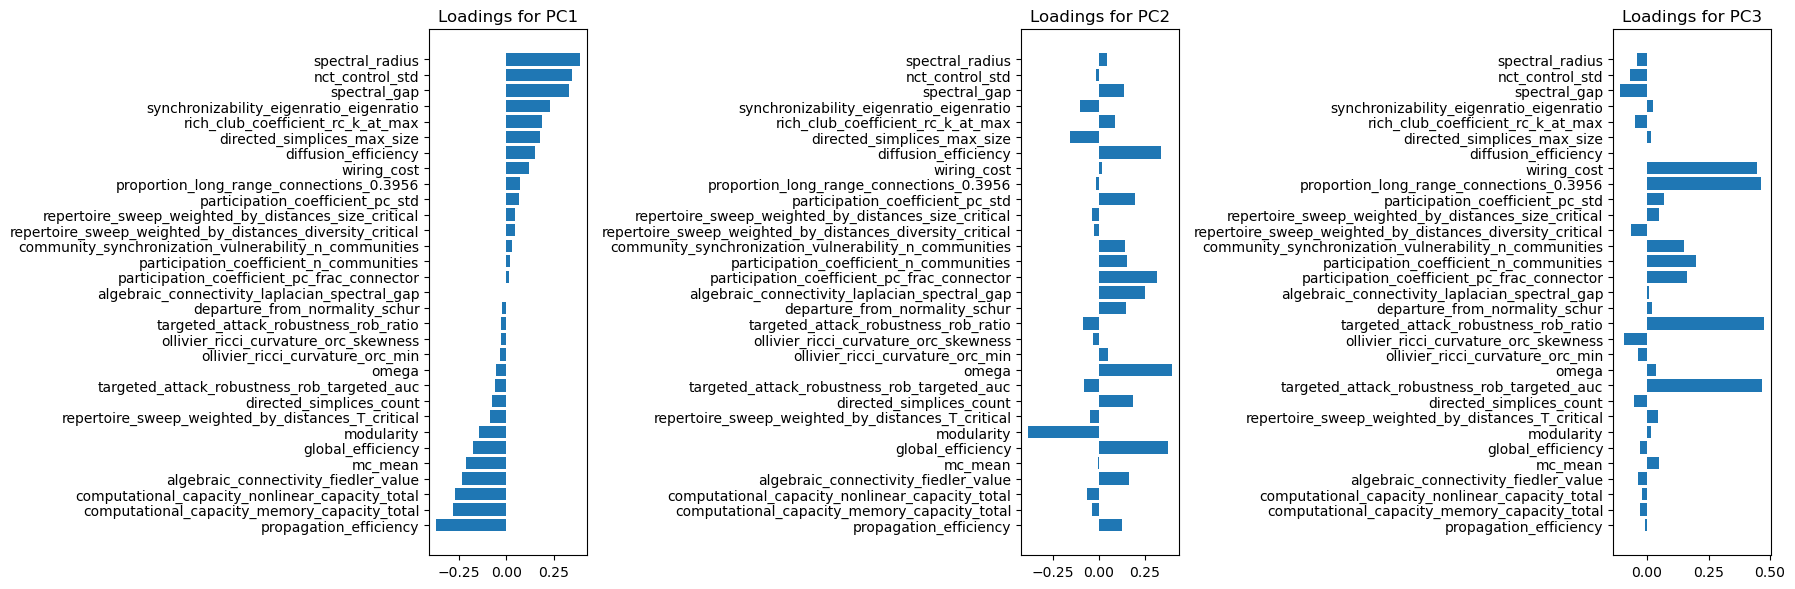

In [162]:

# Subplots of loadings for the first 3 principal components, ONLY top 10 contributors
loadings = pca.components_.T[:, :]
num_metrics = loadings.shape[0]
metric_names = huge_df_properties.columns

# order them all by the absolute value of their loading on the first principal component
sorted_indices = np.argsort((loadings[:, 0])) # [::-1]
loadings = loadings[sorted_indices]
metric_names = metric_names[sorted_indices]

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18,6), dpi=100)
for i in range(3):
    axs[i].barh(range(num_metrics), loadings[:, i])
    axs[i].set_yticks(range(num_metrics))
    axs[i].set_yticklabels(metric_names, rotation=0)
    axs[i].set_title(f"Loadings for PC{i+1}")
plt.tight_layout()
plt.show()


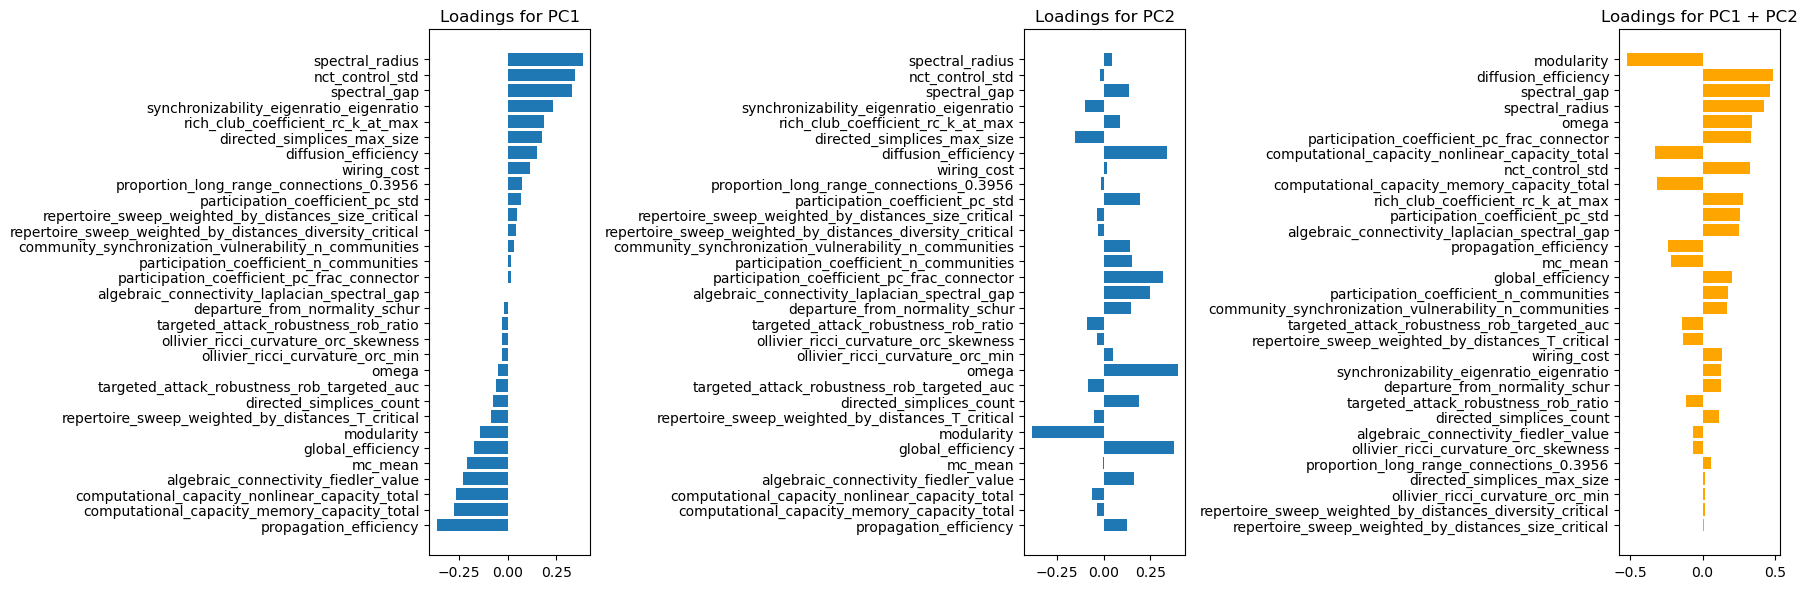

In [163]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18,6), dpi=100)
for i in range(2):
    axs[i].barh(range(num_metrics), loadings[:, i])
    axs[i].set_yticks(range(num_metrics))
    axs[i].set_yticklabels(metric_names, rotation=0)
    axs[i].set_title(f"Loadings for PC{i+1}")

# Plot 3: Addition of PC1 and PC2, ordered by magnitude of PC1+PC2
ordered_pc1_plus_pc2_indices = np.argsort(np.abs(loadings[:, 0] + loadings[:, 1])) #[::-1]
loadings = loadings[ordered_pc1_plus_pc2_indices]
metric_names = metric_names[ordered_pc1_plus_pc2_indices]
axs[2].barh(range(num_metrics), loadings[:, 0] + loadings[:, 1], color="orange")
axs[2].set_yticks(range(num_metrics))
axs[2].set_yticklabels(metric_names, rotation=0)
axs[2].set_title("Loadings for PC1 + PC2")

plt.tight_layout()
plt.show()

In [164]:
# ── Helper: spider plot ───────────────────────────────────────────────────────
def make_spider(ax, values, label, color, axis_labels, title=None):
    """Draw a single radar/spider plot on a polar axis."""
    n = len(axis_labels)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    angles += angles[:1]
    vals = list(values) + [values[0]]
    ax.plot(angles, vals, color=color, linewidth=2, label=label)
    ax.fill(angles, vals, color=color, alpha=0.15)
    ax.set_thetagrids(np.degrees(angles[:-1]), axis_labels, fontsize=7)
    ax.tick_params(pad=6)
    if title:
        ax.set_title(title, fontsize=9, pad=14)


rep_keys   = list(selected_properties.values())
rep_labels = list(selected_properties.keys()) 
rep_idx    = [huge_df_properties.columns.get_loc(k) for k in rep_keys]

# ── Angles for spider (shared across all spider plots) ───────────────────────
n_axes   = len(rep_labels)
angles   = np.linspace(0, 2 * np.pi, n_axes, endpoint=False).tolist()
angles  += angles[:1]


# ── Corner point definitions ──────────────────────────────────────────────────
CORNER_COLORS = {
    "top_left":     "steelblue",
    "bottom_left":  "orange",
    "bottom_right": "forestgreen",
}

def find_corners(pca_result_2d):
    """Return a dict of corner name → row index within pca_result_2d."""
    return {
        "top_left":     int(np.argmax( pca_result_2d[:, 1])),
        "bottom_left":  int(np.argmax(-pca_result_2d[:, 0] - pca_result_2d[:, 1])),
        "bottom_right": int(np.argmax( pca_result_2d[:, 0] - pca_result_2d[:, 1])),
    }

Corner points (full dataset):
  top_left: idx=332, PC1=-0.43, PC2=5.29, dataset=lexis_data_young
  bottom_left: idx=114, PC1=-3.43, PC2=-6.61, dataset=lexis_data_young
  bottom_right: idx=290, PC1=5.77, PC2=-3.92, dataset=lexis_data_young


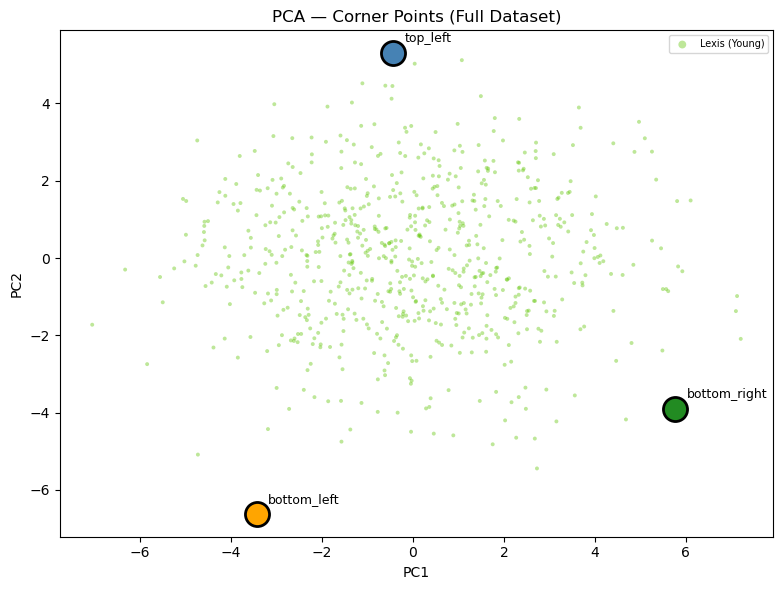

In [165]:
# ── Corners in the full selected-properties PCA space ────────────────────────
corners_full = find_corners(pca_result)

print("Corner points (full dataset):")
for name, idx in corners_full.items():
    ds = huge_df["dataset"].iloc[idx]
    print(f"  {name}: idx={idx}, PC1={pca_result[idx,0]:.2f}, PC2={pca_result[idx,1]:.2f}, dataset={ds}")

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
for ds in huge_df["dataset"].unique():
    mask = (huge_df["dataset"] == ds).values
    ax.scatter(pca_result[mask, 0], pca_result[mask, 1],
               c=COLOR_SCHEME[ds], label=LABEL_MAP.get(ds, ds),
               alpha=0.4, s=8, edgecolors="none")
for name, idx in corners_full.items():
    ax.scatter(pca_result[idx, 0], pca_result[idx, 1],
               s=300, zorder=5, edgecolors="black", linewidths=2,
               color=CORNER_COLORS[name])
    ax.annotate(name, (pca_result[idx, 0], pca_result[idx, 1]),
                textcoords="offset points", xytext=(8, 8), fontsize=9)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA — Corner Points (Full Dataset)")
ax.legend(markerscale=2, fontsize=7)
plt.tight_layout()
plt.show()

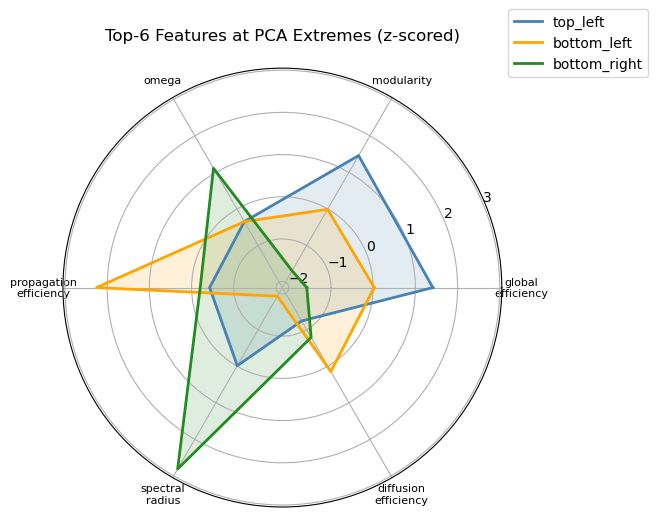

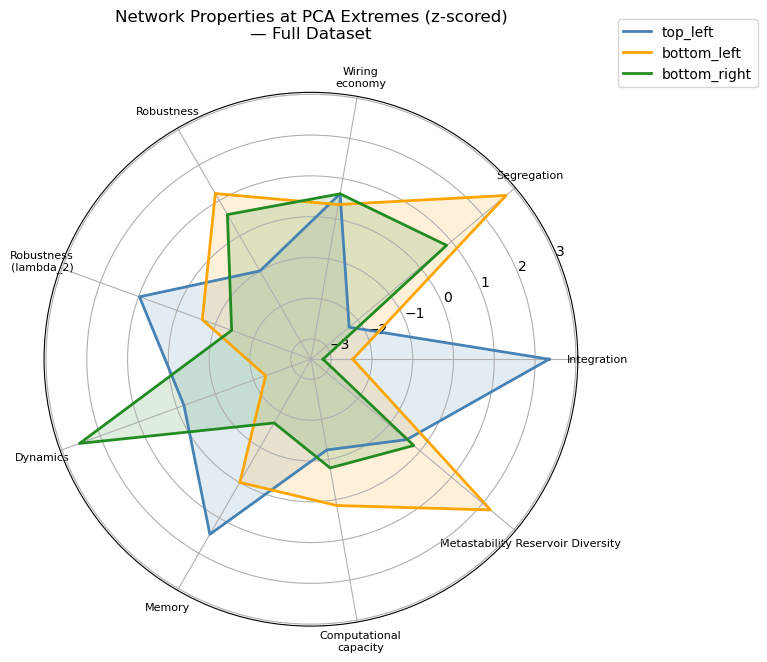

In [166]:
# ── Spider plot for the top-6 features by PC1+PC2 loading magnitude ──────────
top6_idx = np.argsort(np.sqrt(loadings[:, 0]**2 + loadings[:, 1]**2))[::-1][:6]
top6_names  = metric_names[top6_idx]
top6_labels = [n.replace("_", "\n") for n in top6_names]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for name, idx in corners_full.items():
    vals = list(scaled_data[idx, top6_idx]) + [scaled_data[idx, top6_idx[0]]]
    a    = np.linspace(0, 2*np.pi, 6, endpoint=False).tolist() + [0]
    ax.plot(a, vals, color=CORNER_COLORS[name], linewidth=2, label=name)
    ax.fill(a, vals, color=CORNER_COLORS[name], alpha=0.15)
ax.set_thetagrids(np.degrees(np.linspace(0, 2*np.pi, 6, endpoint=False)), top6_labels, fontsize=8)
ax.set_title("Top-6 Features at PCA Extremes (z-scored)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15))
plt.tight_layout()
plt.show()

# ── Spider plot using predefined goal representatives ─────────────────────────
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for name, idx in corners_full.items():
    vals = list(scaled_data[idx, rep_idx]) + [scaled_data[idx, rep_idx[0]]]
    ax.plot(angles, vals, color=CORNER_COLORS[name], linewidth=2, label=name)
    ax.fill(angles, vals, color=CORNER_COLORS[name], alpha=0.15)
ax.set_thetagrids(np.degrees(angles[:-1]), rep_labels, fontsize=8)
ax.set_title("Network Properties at PCA Extremes (z-scored)\n— Full Dataset", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15))
plt.tight_layout()
plt.show()

In [167]:
def draw_axis_group_arcs(ax, feature_labels, angles, arc_radius, groups):
    """
    Draw a bold arc just outside the plot connecting paired spokes.
    arc_radius: draw the arc at this r value (slightly beyond local_max).
    """
    theta_dense = np.linspace(0, 2 * np.pi, 1000)

    for label_a, label_b, color in groups:
        if label_a not in feature_labels or label_b not in feature_labels:
            continue
        i_a = feature_labels.index(label_a)
        i_b = feature_labels.index(label_b)

        angle_a = angles[i_a]
        angle_b = angles[i_b]

        # Always sweep the short way between the two spokes
        if angle_b < angle_a:
            angle_a, angle_b = angle_b, angle_a

        # Choose the shorter arc
        if angle_b - angle_a > np.pi:
            arc_angles = np.linspace(angle_b, angle_a + 2 * np.pi, 80)
        else:
            arc_angles = np.linspace(angle_a, angle_b, 80)

        arc_r = np.full_like(arc_angles, arc_radius)

        ax.plot(arc_angles, arc_r,
                color=color, linewidth=3.5, solid_capstyle="round",
                zorder=0, alpha=0.85)

        # Small dots at each endpoint to cap the arc neatly
        ax.scatter([arc_angles[0], arc_angles[-1]],
                   [arc_radius, arc_radius],
                   color=color, s=18, zorder=7, alpha=0.85)


In [168]:
# from sklearn.metrics import pairwise_distances
# from scipy.stats import f_oneway
# from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# # ── Extract the relevant PCA coordinates + labels ─────────────────────────────

# mami_mask  = (sel_df_label["dataset"] == "suarez_MaMI_dataset").values
# tax_mask   = df_mami[taxonomy].isin(GROUPS_TO_INCLUDE).values
# combined   = mami_mask.copy()
# combined[mami_mask] = tax_mask          # both conditions

# X      = sel_pca_result[combined, :2]   # PC1 + PC2 only
# labels = df_mami[tax_mask][taxonomy].values

# # ── Test 1: PERMANOVA (permutation-based MANOVA on distances) ─────────────────
# # "Are the groups more separated than random chance?"

# from sklearn.utils import shuffle

# def permanova(X, labels, n_permutations=999):
#     def f_stat(X, labels):
#         groups  = [X[labels == g] for g in np.unique(labels)]
#         grand_m = X.mean(axis=0)
#         ss_between = sum(len(g) * ((g.mean(0) - grand_m)**2).sum() for g in groups)
#         ss_within  = sum(((g - g.mean(0))**2).sum() for g in groups)
#         k, n = len(groups), len(X)
#         return (ss_between / (k-1)) / (ss_within / (n-k))

#     observed = f_stat(X, labels)
#     null_dist = [f_stat(X, shuffle(labels)) for _ in range(n_permutations)]
#     p = (np.sum(np.array(null_dist) >= observed) + 1) / (n_permutations + 1)
#     return observed, p

# f_obs, p_perm = permanova(X, labels)
# print(f"PERMANOVA  →  F = {f_obs:.3f},  p = {p_perm:.4f}")

# # ── Test 2: Per-axis ANOVA ─────────────────────────────────────────────────────
# # "Does any single PC axis separate the groups?"

# groups_pc1 = [X[labels == g, 0] for g in np.unique(labels)]
# groups_pc2 = [X[labels == g, 1] for g in np.unique(labels)]
# f1, p1 = f_oneway(*groups_pc1)
# f2, p2 = f_oneway(*groups_pc2)
# print(f"ANOVA PC1  →  F = {f1:.3f},  p = {p1:.4f}")
# print(f"ANOVA PC2  →  F = {f2:.3f},  p = {p2:.4f}")

# # ── Test 3: LDA cross-validated accuracy ──────────────────────────────────────
# # "Can we predict group membership better than chance?"

# from sklearn.model_selection import cross_val_score
# lda      = LinearDiscriminantAnalysis()
# cv_score = cross_val_score(lda, X, labels, cv=5, scoring="accuracy").mean()
# chance   = 1 / len(np.unique(labels))
# print(f"LDA 5-fold CV accuracy = {cv_score:.3f}  (chance = {chance:.3f})")

# Ages 

In [169]:
for dataset_name, d in dict_with_all_datasets.items():
    

    # if "lexis_data_young" in dataset_name:
    if "lexis_data_" in dataset_name:
    
            print(dataset_name)
            ages = np.load(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/{dataset_name}/04_further_info/00_ages.npy")
            # Turn dict_with_all_datasets["lexis_data_aging"].index into a mask
            
            mask = np.zeros_like(ages)
            mask[dict_with_all_datasets[dataset_name].index] = 1
            mask = mask.astype(bool)
            
            # add an age column by index to the main dataframe
            dict_with_all_datasets[dataset_name]["age"] = ages[mask]
        

lexis_data_young
lexis_data_aging
lexis_data_developing


In [170]:
huge_df = pd.DataFrame()

# combine all the metrics into one dataframe for this experiment
for dataset_name in ordered_dataset_names: 
    df = dict_with_all_datasets[dataset_name]
    # Add a column to identify the dataset
    df["dataset"] = dataset_name
    
    print(dataset_name, len(df))
    # Remove this, as eta, gamma, etc are not defined here? 
    if dataset_name == "kaysons_generated_networks_topology" or dataset_name == "hcp_schaefer_100_dataset": 
        print(" ---> skipped")
        continue
    huge_df = pd.concat([huge_df, df], ignore_index=True)
    

lexis_data_young 703


In [171]:
huge_df

,transitivity,avg_clustering,modularity,degree_gini,degree_assortativity,omega,structural_complexity,directed_simplices_count,directed_simplices_max_size,char_path_length,...,computational_capacity_memory_nonlinear_ratio,computational_capacity_total_capacity,computational_capacity_state_dimensionality,computational_capacity_state_entropy,computational_capacity_state_rank,computational_capacity_separation_ratio,computational_capacity_lyapunov_exponent,mc_mean,dataset,age
0,0.447657,0.500467,0.502173,0.271475,0.311591,0.088988,0.752183,164.0,9.0,2.799798,...,0.711990,20.115900,1.417760,0.532775,100.0,1.958217,-0.140315,8.703271,lexis_data_young,20.0
1,0.421781,0.479110,0.482583,0.265596,0.200417,0.136855,0.763829,168.0,8.0,2.757778,...,0.718483,22.192609,1.467275,0.596728,100.0,1.962743,-0.113200,8.568311,lexis_data_young,27.0
2,0.433155,0.465811,0.481428,0.298828,0.274818,0.165312,0.745449,157.0,9.0,2.757374,...,0.711876,20.177980,1.307521,0.473058,100.0,1.966536,-0.120126,8.479803,lexis_data_young,27.0
3,0.426840,0.436832,0.471413,0.261717,0.347657,0.182278,0.764888,172.0,9.0,2.784646,...,0.715152,22.320992,1.513297,0.628864,100.0,1.958587,-0.119530,8.613952,lexis_data_young,33.0
4,0.442505,0.465549,0.423224,0.308725,0.431438,0.156259,0.744151,180.0,9.0,2.813535,...,0.721773,19.749880,1.359903,0.520695,100.0,1.969301,-0.128243,8.148274,lexis_data_young,27.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
698,0.411829,0.479076,0.483902,0.269192,0.218169,0.155750,0.763628,169.0,8.0,2.654949,...,0.699331,20.918523,1.366789,0.523674,100.0,1.973266,-0.125751,8.627804,lexis_data_young,33.0
699,0.434652,0.471401,0.471395,0.285778,0.401153,0.162929,0.751906,176.0,8.0,2.778182,...,0.696613,19.315814,1.409184,0.542574,100.0,1.972584,-0.135078,8.286215,lexis_data_young,22.0
700,0.442375,0.488509,0.472723,0.301296,0.474166,0.112381,0.749993,163.0,9.0,2.841414,...,0.717708,20.979763,1.509228,0.611619,100.0,1.948116,-0.135819,8.220144,lexis_data_young,35.0
701,0.418342,0.458682,0.461759,0.277172,0.269990,0.186519,0.759630,166.0,8.0,2.679192,...,0.721018,19.506193,1.280706,0.450606,100.0,1.979478,-0.115734,8.498594,lexis_data_young,29.0


Dropped columns: []


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_58056/944546758.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


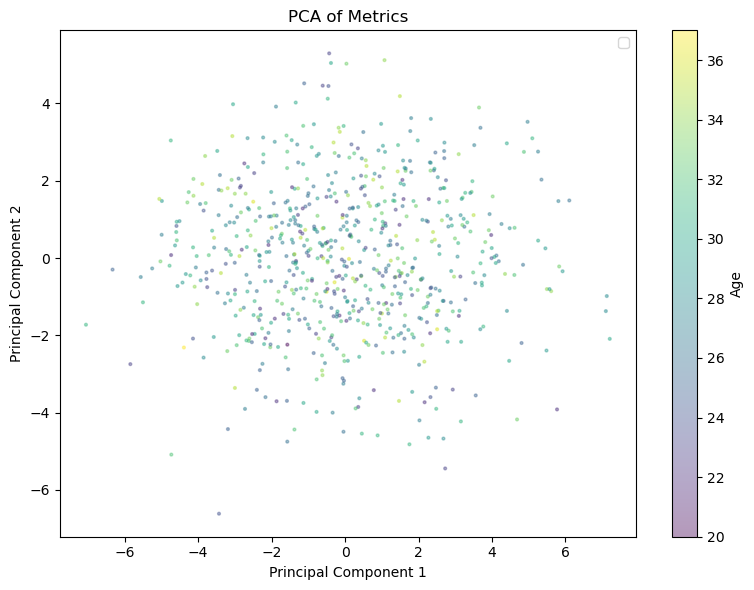

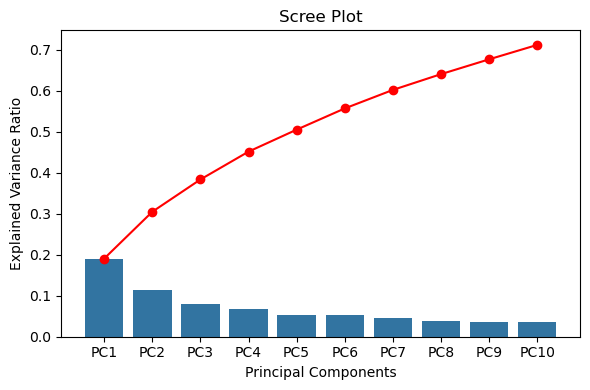

In [172]:


# Drop the columns that have inf or -inf values (if any). Print the dropped columns
dropped_cols = huge_df_properties.columns[huge_df_properties.isnull().any()].tolist()
huge_df_properties.replace([np.inf, -np.inf], np.nan, inplace=True)
huge_df_properties.dropna(axis=1, inplace=True)
print(f"Dropped columns: {dropped_cols}")

scaler = StandardScaler()
scaled_data = scaler.fit_transform(huge_df_properties)

pca = PCA(n_components=10) # 10)
pca_result = pca.fit_transform(scaled_data)

plt.figure(figsize=(8,6))
plt.scatter(x=pca_result[:,0], 
            y=pca_result[:,1], 
            s=4,
            alpha=0.4, 
            c=huge_df["age"],
            # c=huge_df['color_dataset'], 
            # label=huge_df['dataset']
        )
plt.title("PCA of Metrics")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.colorbar(label="Age") # if using age as color
plt.show()

# Scree plot to show explained variance
explained_variance = pca.explained_variance_ratio_
plt.figure(figsize=(6,4))
sns.barplot(x=[f"PC{i+1}" for i in range(len(explained_variance))], y=explained_variance)
plt.plot(range(0, len(explained_variance)), np.cumsum(explained_variance), marker="o", color="red",
        label="Cumulative")
plt.title("Scree Plot")
plt.ylabel("Explained Variance Ratio")
plt.xlabel("Principal Components")
plt.tight_layout()
plt.show()

In [173]:
# # Create a PCA between the columns of the huge_df
# from sklearn.decomposition import PCA
# from sklearn.preprocessing import StandardScaler

# # Drop the columns that have inf or -inf values (if any). Print the dropped columns
# dropped_cols = huge_df_properties.columns[huge_df_properties.isnull().any()].tolist()
# huge_df_properties.replace([np.inf, -np.inf], np.nan, inplace=True)
# huge_df_properties.dropna(axis=1, inplace=True)
# print(f"Dropped columns: {dropped_cols}")

# scaler = StandardScaler()
# scaled_data = scaler.fit_transform(huge_df_properties)

# pca = PCA(n_components=10) # 10)
# pca_result = pca.fit_transform(scaled_data)

# plt.figure(figsize=(8,6))
# plt.scatter(x=pca_result[:,0], 
#             y=pca_result[:,1], 
#             s=4,
#             alpha=0.4, 
#             c=huge_df["age"],
#             # c=huge_df['color_dataset'], 
#             # label=huge_df['dataset']
#         )
# plt.title("PCA of Metrics")
# plt.xlabel("Principal Component 1")
# plt.ylabel("Principal Component 2")
# plt.legend()
# plt.tight_layout()
# plt.colorbar(label="Age") # if using age as color
# plt.show()

In [174]:
len(huge_df_properties)

703

Dropped columns: []
/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/01_lexi_ages/lexis_data_young_pca_age_scatter_individuals.pdf


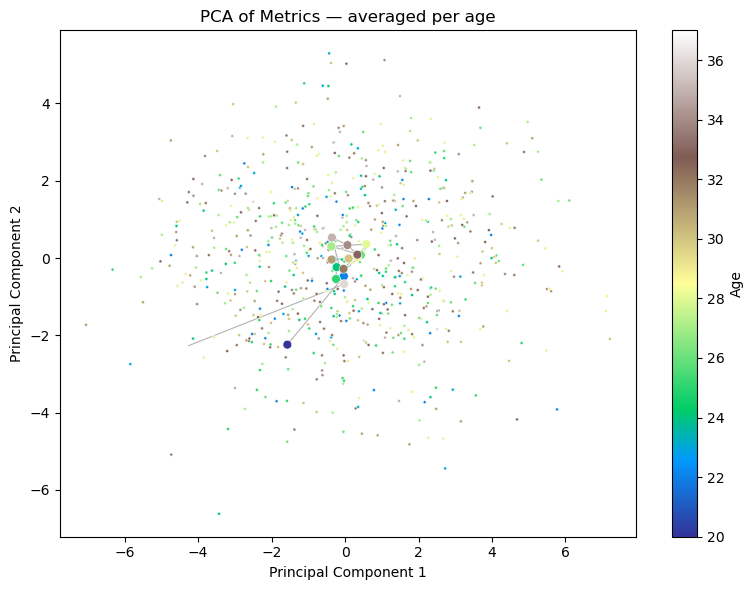

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/01_lexi_ages/lexis_data_young_pca_scree_plot.pdf


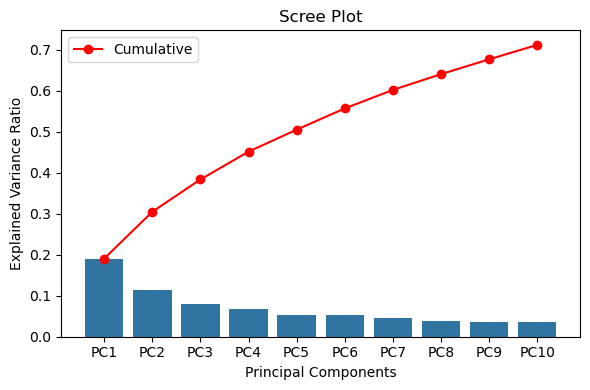

In [175]:

# ── 1. Clean ──────────────────────────────────────────────────────────────────
dropped_cols = huge_df_properties.columns[huge_df_properties.isnull().any()].tolist()
huge_df_properties.replace([np.inf, -np.inf], np.nan, inplace=True)
huge_df_properties.dropna(axis=1, inplace=True)
print(f"Dropped columns: {dropped_cols}")

# ── 2. Scale & PCA on the full data ───────────────────────────────────────────
scaler = StandardScaler()
scaled_data = scaler.fit_transform(huge_df_properties)

pca = PCA(n_components=10)
pca_result = pca.fit_transform(scaled_data)

# ── 3. Average PC scores per age ──────────────────────────────────────────────
pca_df = pd.DataFrame(pca_result[:, :2], columns=["PC1", "PC2"])
pca_df["age"] = huge_df["age"].values

age_means = pca_df.groupby("age")[["PC1", "PC2"]].mean().reset_index().sort_values("age")

# ── 4. PCA scatter: averaged dots coloured by age, connected by line ──────────
fig, ax = plt.subplots(figsize=(8, 6))

norm = plt.Normalize(age_means["age"].min(), age_means["age"].max())
cmap = plt.cm.terrain # viridis

# Line through the age-averaged points (sorted by age)
ax.plot(age_means["PC1"], age_means["PC2"],
        color="grey", linewidth=0.8, alpha=0.6, zorder=1)

# All individual ones
sc = ax.scatter(pca_df["PC1"], 
                pca_df["PC2"],
                c=pca_df["age"], cmap=cmap, norm=norm,
                s=5, 
                zorder=2, edgecolors="white", 
                linewidths=0.4)

# One dot per age, coloured by age
sc = ax.scatter(age_means["PC1"], age_means["PC2"],
                c=age_means["age"], cmap=cmap, norm=norm,
                s=40, zorder=2, edgecolors="white", linewidths=0.4)

plt.colorbar(sc, ax=ax, label="Age")
ax.set_title("PCA of Metrics — averaged per age")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
plt.tight_layout()

plt.savefig(output_folder / f"{dataset_name}_pca_age_scatter_individuals.pdf", dpi=150, bbox_inches="tight")
print(output_folder / f"{dataset_name}_pca_age_scatter_individuals.pdf")
plt.show()

# ── 5. Scree plot ─────────────────────────────────────────────────────────────
explained_variance = pca.explained_variance_ratio_
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=[f"PC{i+1}" for i in range(len(explained_variance))],
            y=explained_variance, ax=ax)
ax.plot(range(len(explained_variance)), np.cumsum(explained_variance),
        marker="o", color="red", label="Cumulative")
ax.set_title("Scree Plot")
ax.set_ylabel("Explained Variance Ratio")
ax.set_xlabel("Principal Components")
ax.legend()
plt.tight_layout()

plt.savefig(output_folder / f"{dataset_name}_pca_scree_plot.pdf", dpi=150, bbox_inches="tight")
print(output_folder / f"{dataset_name}_pca_scree_plot.pdf")
plt.show()

In [176]:
# # ── After computing age_means (sorted by age) ────────────────────────────────

# # Smooth PC1 and PC2 as a function of age using a smoothing spline
# age_vals = age_means["age"].values
# t = np.linspace(age_vals.min(), age_vals.max(), 300)  # fine grid for smooth curve

# spl_pc1 = make_smoothing_spline(age_vals, age_means["PC1"].values, lam=5)
# spl_pc2 = make_smoothing_spline(age_vals, age_means["PC2"].values, lam=5)

# smooth_pc1 = spl_pc1(t)
# smooth_pc2 = spl_pc2(t)

# # ── Plot ──────────────────────────────────────────────────────────────────────
# fig, ax = plt.subplots(figsize=viz.cm_to_inch((12,9))) # (8, 6)

# norm = plt.Normalize(age_vals.min(), age_vals.max())
# cmap = plt.cm.terrain # gist_rainbow # viridis

# # Smoothed line coloured by age using a LineCollection
# from matplotlib.collections import LineCollection

# points = np.array([smooth_pc1, smooth_pc2]).T.reshape(-1, 1, 2)
# segments = np.concatenate([points[:-1], points[1:]], axis=1)
# lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=1.5, alpha=0.8, zorder=1)
# lc.set_array(t)  # colour the line by age along its length
# ax.add_collection(lc)

# # Raw averaged dots on top
# sc = ax.scatter(age_means["PC1"], age_means["PC2"],
#                 c=age_means["age"],
#                 cmap=cmap, norm=norm,
#                 s=40, zorder=2, edgecolors="white", linewidths=0.4)

# ax.autoscale()
# plt.colorbar(sc, ax=ax, label="Age")
# ax.set_title(f"{dataset_name.replace('_', ' ').capitalize()}: Averaged per age (after PCA)")
# ax.set_xlabel("PC1")
# ax.set_ylabel("PC2")


# scale = np.sqrt(pca.explained_variance_[:2])  # [√λ1, √λ2]

# loadings = pd.DataFrame(
#     (pca.components_[:2] * scale[:, None]).T,  # scale each PC axis
#     index=huge_df_properties.columns,
#     columns=["PC1", "PC2"]
# )

# # Top 3 by absolute loading on PC1 and PC2 (union, deduplicated)
# n_largest = 2
# top_pc1 = loadings["PC1"].abs().nlargest(n_largest).index.tolist()
# top_pc2 = loadings["PC2"].abs().nlargest(n_largest).index.tolist()
# top_vars = list(dict.fromkeys(top_pc1 + top_pc2))  # preserve order, no duplicates

# # ── Inset axes in bottom-right corner ────────────────────────────────────────
# size_inset = viz.cm_to_inch((1,1))[0]
# shift_from_corner = 0.02
# ax_inset = ax.inset_axes([1-size_inset-shift_from_corner, 
#                           1-size_inset-shift_from_corner, 
#                           size_inset, 
#                           size_inset])  # [x, y, w, h] in axes coords
# # ax_inset.set_facecolor("#f7f7f7")
# ax_inset.axhline(0, color="grey", linewidth=0.5, alpha=0.5)
# ax_inset.axvline(0, color="grey", linewidth=0.5, alpha=0.5)
# # # remove frame
# # for spine in ax_inset.spines.values():
# #     spine.set_visible(False)

# for var in top_vars:
#     vx = loadings.loc[var, "PC1"]
#     vy = loadings.loc[var, "PC2"]
#     label = PROPERTY_NAMES.get(var, var)
#     label = "\n".join(label.split(" "))  # split long names into multiple lines

#     # Colour by which PC it ranks highest on
#     colour = "#E63946" if var in top_pc1 else "#457B9D"
#     if var in top_pc1 and var in top_pc2:
#         colour = "#9B2226"  # appears in both — use distinct colour

#     ax_inset.quiver(
#         0, 0, vx, vy,
#         angles="xy", scale_units="xy", scale=1,  # ← these three together = exact data coords
#         color=colour, width=0.015,
#         headwidth=4, headlength=5, headaxislength=4,
#         zorder=5,
#     )
    
#     #     ax_inset.annotate(
#     #     "", xy=(vx, vy), xytext=(0, 0),
#     #     arrowprops=dict(arrowstyle="-|>", color=colour, lw=1.2,
#     #                     mutation_scale=3) # 6)
#     # )
#     # Nudge label slightly beyond arrow tip
#     ax_inset.text(vx * 1.5, 
#                   vy * 1.15, 
#                   label,
#                   fontsize=5.5, ha="center", va="center",
#                   color=colour, fontweight="bold")

# # Square, symmetric axes limits with a little padding
# # max_val = max(loadings.loc[top_vars, ["PC1", "PC2"]].values.max(), 0) + 0.25 # .4)
# # min_val = min(loadings.loc[top_vars, ["PC1", "PC2"]].values.min(), 0) - 0.25 # .4)
# # ax_inset.set_xlim(min_val, max_val)
# # ax_inset.set_ylim(min_val, max_val)

# max_val_x = max(loadings.loc[top_vars, ["PC1"]].values.max(), 0) + 0.25 # .4)
# min_val_x = min(loadings.loc[top_vars, ["PC1"]].values.min(), 0) - 0.25 # .4)

# max_val_y = max(loadings.loc[top_vars, ["PC2"]].values.max(), 0) + 0.25 # .4)
# min_val_y = min(loadings.loc[top_vars, ["PC2"]].values.min(), 0) - 0.25 # .4)

# ax_inset.set_xlim(min_val_x, max_val_x)
# ax_inset.set_ylim(min_val_y, max_val_y)


# # ax_inset.set_xlim(-max_val, max_val)
# # ax_inset.set_ylim(-max_val, max_val)
# # ax_inset.set_aspect("equal")
# # ax_inset.set_xlabel("PC1") # , fontsize=6, labelpad=1)
# # ax_inset.set_ylabel("PC2") # , fontsize=6, labelpad=1)
# ax_inset.tick_params() # labelsize=5)
# # 

# plt.savefig(output_folder / f"{dataset_name}_pca_age.pdf", dpi=300)
# print(output_folder / f"{dataset_name}_pca_age.pdf")

# plt.show()

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/01_lexi_ages/lexis_data_young_pca_age.pdf


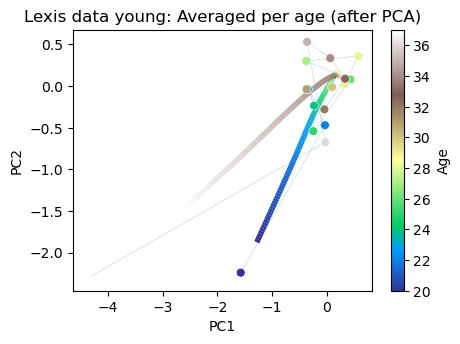

In [177]:
age_vals = age_means["age"].values
t = np.linspace(age_vals.min(), age_vals.max(), 300)

smooth_pc1 = make_smoothing_spline(age_vals, age_means["PC1"].values, lam=5)(t)
smooth_pc2 = make_smoothing_spline(age_vals, age_means["PC2"].values, lam=5)(t)

norm = plt.Normalize(age_vals.min(), age_vals.max())
cmap = plt.cm.terrain

# ── Loadings ──────────────────────────────────────────────────────────────────
scale    = np.sqrt(pca.explained_variance_[:2])
loadings = pd.DataFrame(
    (pca.components_[:2] * scale[:, None]).T,
    index=huge_df_properties.columns,
    columns=["PC1", "PC2"]
)
n_largest = 2
top_pc1   = loadings["PC1"].abs().nlargest(n_largest).index.tolist()
top_pc2   = loadings["PC2"].abs().nlargest(n_largest).index.tolist()
top_vars  = list(dict.fromkeys(top_pc1 + top_pc2))

# ════════════════════════════════════════════════════════════════════════════
# PLOT 1 — age trajectory
# ════════════════════════════════════════════════════════════════════════════
fig1, ax = plt.subplots(figsize=viz.cm_to_inch((12, 9)))

points   = np.array([smooth_pc1, smooth_pc2]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
lc = LineCollection(segments, cmap=cmap, 
                    norm=norm, 
                    linewidth=4, # 2, # 1.5, 
                    alpha=1, # 0.8, 
                    zorder=2
                    )
lc.set_array(t)
ax.add_collection(lc)

sc = ax.scatter(age_means["PC1"], age_means["PC2"],
                c=age_means["age"], cmap=cmap, norm=norm,
                s=40, 
                zorder=3, 
                edgecolors="white", linewidths=0.4)

lines_ax = ax.plot(age_means["PC1"], 
             age_means["PC2"], # age_means is already ordered. 
                # c=age_means["age"], 
                # cmap=cmap, 
                # norm=norm,
                zorder=1, 
                linewidth=0.2,
                alpha=0.6,
                # edgecolors="white", 
                # linewidths=0.2
                )
# print(age_means["age"])
ax.autoscale()
fig1.colorbar(sc, ax=ax, label="Age")
ax.set_title(f"{dataset_name.replace('_', ' ').capitalize()}: Averaged per age (after PCA)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")

fig1.tight_layout()
fig1.savefig(output_folder / f"{dataset_name}_pca_age.pdf", dpi=300)
print(output_folder / f"{dataset_name}_pca_age.pdf")
plt.show()


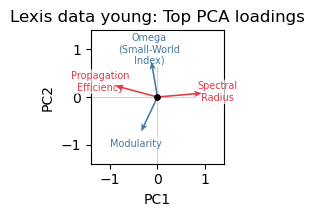

In [178]:

# ════════════════════════════════════════════════════════════════════════════
# PLOT 2 — loading vectors
# ════════════════════════════════════════════════════════════════════════════
fig2, ax2 = plt.subplots(figsize=viz.cm_to_inch((6,6)))

ax2.axhline(0, color="grey", lw=0.5, alpha=0.5)
ax2.axvline(0, color="grey", lw=0.5, alpha=0.5)
ax2.scatter([0], [0], color="black", s=15, zorder=6)

label_positions = []  # track placed labels to nudge overlaps

from adjustText import adjust_text

texts = []
for var in top_vars:
    vx     = loadings.loc[var, "PC1"]
    vy     = loadings.loc[var, "PC2"]
    colour = "#E63946" if var in top_pc1 else "#457B9D"
    if var in top_pc1 and var in top_pc2:
        colour = "#9B2226"

    ax2.quiver(
        0, 0, vx, vy,
        angles="xy", scale_units="xy", scale=1,
        color=colour, width=0.012,
        headwidth=4, headlength=5, headaxislength=4,
        zorder=5,
    )
    texts.append((var, vx, vy, colour))

# ── Fan apart labels that are too close in angle ──────────────────────────────
MIN_LABEL_DIST = 0.25  # minimum distance between label positions
LABEL_RADIUS   = 1.35  # how far beyond arrow tip

label_positions = []
for var, vx, vy, colour in texts:
    norm_r = np.sqrt(vx**2 + vy**2)
    lx = vx / norm_r * norm_r * LABEL_RADIUS
    ly = vy / norm_r * norm_r * LABEL_RADIUS

    # Fan away from already-placed labels along the perpendicular
    for attempt in range(20):
        too_close = [(px, py) for px, py in label_positions
                     if np.sqrt((lx-px)**2 + (ly-py)**2) < MIN_LABEL_DIST]
        if not too_close:
            break
        # Rotate label position slightly around origin
        angle = np.arctan2(ly, lx) + 0.15
        r     = np.sqrt(lx**2 + ly**2)
        lx, ly = r * np.cos(angle), r * np.sin(angle)

    label_positions.append((lx, ly))
    label = PROPERTY_NAMES.get(var, var).replace(" ", "\n")
    ax2.text(lx, ly, label,
             fontsize=7, ha="center", va="center",
             color=colour, #  fontweight="bold",
             bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7))


# Axis limits: symmetric, tight around actual vectors + label room
all_vals = loadings.loc[top_vars, ["PC1", "PC2"]].abs().values.max() * 1.5
ax2.set_xlim(-all_vals, all_vals)
ax2.set_ylim(-all_vals, all_vals)
ax2.set_aspect("equal")
ax2.set_xlabel("PC1") # , fontsize=9)
ax2.set_ylabel("PC2") # , fontsize=9)
ax2.set_title(f"{dataset_name.replace('_', ' ').capitalize()}: Top PCA loadings") # , fontsize=9)
ax2.tick_params() # labelsize=7)


fig2.tight_layout()
# fig2.savefig(output_folder / f"{dataset_name}_pca_loadings.pdf", dpi=300)
# print(output_folder / f"{dataset_name}_pca_loadings.pdf")
plt.show()

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/01_lexi_ages/lexis_data_young_pca_loadings.pdf


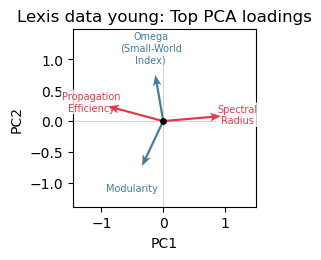

In [179]:
# ── Fan labels by enforcing minimum angular separation ────────────────────────
LABEL_RADIUS  = 1.2   # in data units, beyond arrow tip
MIN_ANG_GAP   = 0.8 # radians (~20°) minimum between labels

# Collect arrows + initial angles
arrow_info = []
for var in top_vars:
    vx = loadings.loc[var, "PC1"]
    vy = loadings.loc[var, "PC2"]
    colour = "#E63946" if var in top_pc1 else "#457B9D"
    if var in top_pc1 and var in top_pc2:
        colour = "#9B2226"
    angle = np.arctan2(vy, vx)
    r     = np.sqrt(vx**2 + vy**2)
    arrow_info.append(dict(var=var, vx=vx, vy=vy, colour=colour, angle=angle, r=r))

# Sort by angle so we can spread neighbours apart
arrow_info.sort(key=lambda d: d["angle"])

# Push angles apart until all gaps >= MIN_ANG_GAP (a few passes suffice)
label_angles = [d["angle"] for d in arrow_info]
for _ in range(50):
    changed = False
    for i in range(len(label_angles)):
        j = (i + 1) % len(label_angles)
        gap = label_angles[j] - label_angles[i]
        if i == len(label_angles) - 1:        # wrap-around pair
            gap += 2 * np.pi
        if gap < MIN_ANG_GAP:
            push = (MIN_ANG_GAP - gap) / 2
            label_angles[i] -= push
            label_angles[j] += push
            changed = True
    if not changed:
        break

# ── Draw ──────────────────────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=viz.cm_to_inch((7, 7)))
ax2.axhline(0, color="grey", lw=0.5, alpha=0.5)
ax2.axvline(0, color="grey", lw=0.5, alpha=0.5)
ax2.scatter([0], [0], color="black", s=15, zorder=6)

label_coords = []
for d, langle in zip(arrow_info, label_angles):
    ax2.quiver(0, 0, d["vx"], d["vy"],
               angles="xy", scale_units="xy", scale=1,
               color=d["colour"], width=0.012,
               headwidth=4, headlength=5, headaxislength=4, zorder=5)

    # Label position: at LABEL_RADIUS along the (possibly fanned) angle
    lx = LABEL_RADIUS * np.cos(langle)
    ly = LABEL_RADIUS * np.sin(langle)
    label_coords.append((lx, ly))

    # Thin connector from arrow tip to label if angle was moved
    # tip_x, tip_y = d["vx"] * 1.05, d["vy"] * 1.05
    # if abs(langle - d["angle"]) > 0.05:
    #     ax2.plot([tip_x, lx], [tip_y, ly],
    #              color=d["colour"], lw=0.5, alpha=0.6, zorder=4)

    label = PROPERTY_NAMES.get(d["var"], d["var"]).replace(" ", "\n")
    ax2.text(lx, ly, label,
             fontsize=7, ha="center", va="center",
             color=d["colour"],
             bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.8))

# Axis limits: fit both arrows and labels
all_lx = [lx for lx, ly in label_coords]
all_ly = [ly for lx, ly in label_coords]
pad = 0.3
ax2.set_xlim(min(min(all_lx), -0.5) - pad, max(max(all_lx), 0.5) + pad)
ax2.set_ylim(min(min(all_ly), -0.5) - pad, max(max(all_ly), 0.5) + pad)
ax2.set_aspect("equal")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.set_title(f"{dataset_name.replace('_', ' ').capitalize()}: Top PCA loadings")

fig2.tight_layout()
fig2.savefig(output_folder / f"{dataset_name}_pca_loadings.pdf", dpi=300)
print(output_folder / f"{dataset_name}_pca_loadings.pdf")
plt.show()

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/01_lexi_ages/lexis_data_young_pca_optimizers.pdf


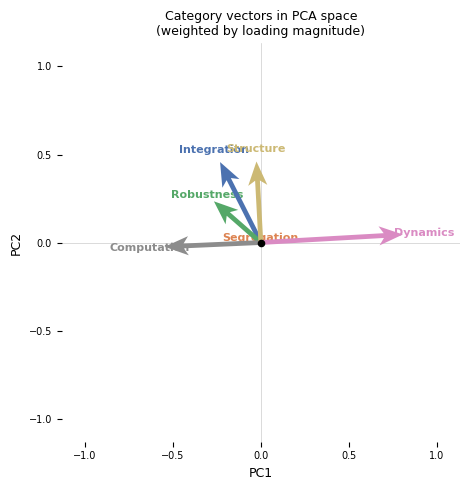

In [180]:
# ── Category-level aggregate vectors ─────────────────────────────────────────
# loadings: DataFrame (n_vars × 2), already scaled by √eigenvalue

cat_vectors = {}
for cat, colour in CATEGORY_COLOURS.items():
    # Variables in this category that also have loadings
    cat_vars = [c for c in loadings.index
                if c in meta.index and meta.loc[c, "Category"] == cat]
    if not cat_vars:
        continue

    cat_loads = loadings.loc[cat_vars]  # shape: (n_cat_vars, 2)

    # Weight each variable by its total loading magnitude (L2 norm across PC1+PC2)
    weights = np.sqrt(cat_loads["PC1"]**2 + cat_loads["PC2"]**2)
    weights = weights / weights.sum()  # normalise to sum=1

    # Weighted sum → one (PC1, PC2) vector per category
    vx = (cat_loads["PC1"] * weights).sum()
    vy = (cat_loads["PC2"] * weights).sum()
    cat_vectors[cat] = (vx, vy)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5))

ax.axhline(0, color="grey", lw=0.5, alpha=0.4)
ax.axvline(0, color="grey", lw=0.5, alpha=0.4)
ax.scatter([0], [0], color="black", s=20, zorder=6)

for cat, (vx, vy) in cat_vectors.items():
    colour = CATEGORY_COLOURS[cat]
    ax.quiver(
        0, 0, vx, vy,
        angles="xy", scale_units="xy", scale=1,
        color=colour, width=0.012,
        headwidth=4, headlength=5, headaxislength=4,
        zorder=5,
    )
    nudge = 1.15
    ax.text(vx * nudge, vy * nudge, cat,
            fontsize=8, ha="center", va="center",
            color=colour, fontweight="bold")

# Symmetric axis limits
max_val = max(np.sqrt(vx**2 + vy**2) for vx, vy in cat_vectors.values()) * 1.4
ax.set_xlim(-max_val, max_val)
ax.set_ylim(-max_val, max_val)
ax.set_aspect("equal")
ax.set_xlabel("PC1", fontsize=9)
ax.set_ylabel("PC2", fontsize=9)
ax.set_title("Category vectors in PCA space\n(weighted by loading magnitude)", fontsize=9)

# Remove frame, keep ticks
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(labelsize=7)

plt.tight_layout()

plt.savefig(output_folder / f"{dataset_name}_pca_optimizers.pdf", dpi=300)
print(output_folder / f"{dataset_name}_pca_optimizers.pdf")
plt.show()

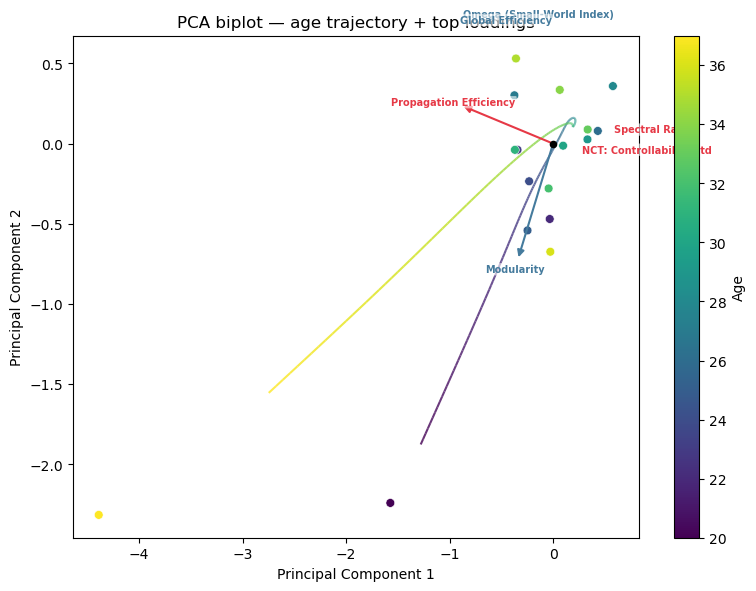

In [181]:
from scipy.interpolate import make_smoothing_spline
from matplotlib.collections import LineCollection

# ── 1. Scaled biplot loadings ─────────────────────────────────────────────────
scale = np.sqrt(pca.explained_variance_[:2])
loadings = pd.DataFrame(
    (pca.components_[:2] * scale[:, None]).T,
    index=huge_df_properties.columns,
    columns=["PC1", "PC2"]
)

n_largest = 3
top_pc1 = loadings["PC1"].abs().nlargest(n_largest).index.tolist()
top_pc2 = loadings["PC2"].abs().nlargest(n_largest).index.tolist()
top_vars = list(dict.fromkeys(top_pc1 + top_pc2))

# ── 2. Smoothed age trajectory ────────────────────────────────────────────────
age_vals = age_means["age"].values
t        = np.linspace(age_vals.min(), age_vals.max(), 300)

smooth_pc1 = make_smoothing_spline(age_vals, age_means["PC1"].values, lam=5)(t)
smooth_pc2 = make_smoothing_spline(age_vals, age_means["PC2"].values, lam=5)(t)

# ── 3. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

norm = plt.Normalize(age_vals.min(), age_vals.max())
cmap = plt.cm.viridis

# Smoothed trajectory as a coloured line
points   = np.array([smooth_pc1, smooth_pc2]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=1.5, alpha=0.8, zorder=1)
lc.set_array(t)
ax.add_collection(lc)

# Age-averaged dots
sc = ax.scatter(age_means["PC1"], age_means["PC2"],
                c=age_means["age"], cmap=cmap, norm=norm,
                s=40, zorder=2, edgecolors="white", linewidths=0.4)

# ── 4. Biplot arrows — overlaid directly in score space ──────────────────────
# The arrows live in the same coordinate system as the scatter, so no inset needed.
# We add a second y-axis label on the right to signal the dual scale if needed,
# but typically a single shared axis works cleanly.

for var in top_vars:
    vx = loadings.loc[var, "PC1"]
    vy = loadings.loc[var, "PC2"]
    label = PROPERTY_NAMES.get(var, var)

    colour = "#E63946" if var in top_pc1 else "#457B9D"
    if var in top_pc1 and var in top_pc2:
        colour = "#9B2226"

    ax.annotate(
        "", xy=(vx, vy), xytext=(0, 0),
        arrowprops=dict(
            arrowstyle="-|>",
            color=colour, lw=1.5,
            mutation_scale=10,
        ),
        zorder=5,
    )
    # Place label just beyond the arrow tip
    nudge = 1.08
    ax.text(vx * nudge, vy * nudge, label,
            fontsize=7, ha="center", va="center",
            color=colour, fontweight="bold", zorder=6,
            bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.6))

# Origin marker
ax.scatter([0], [0], color="black", s=20, zorder=6)

# ── 5. Dress ──────────────────────────────────────────────────────────────────
ax.autoscale()
plt.colorbar(sc, ax=ax, label="Age")
ax.set_title("PCA biplot — age trajectory + top loadings")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

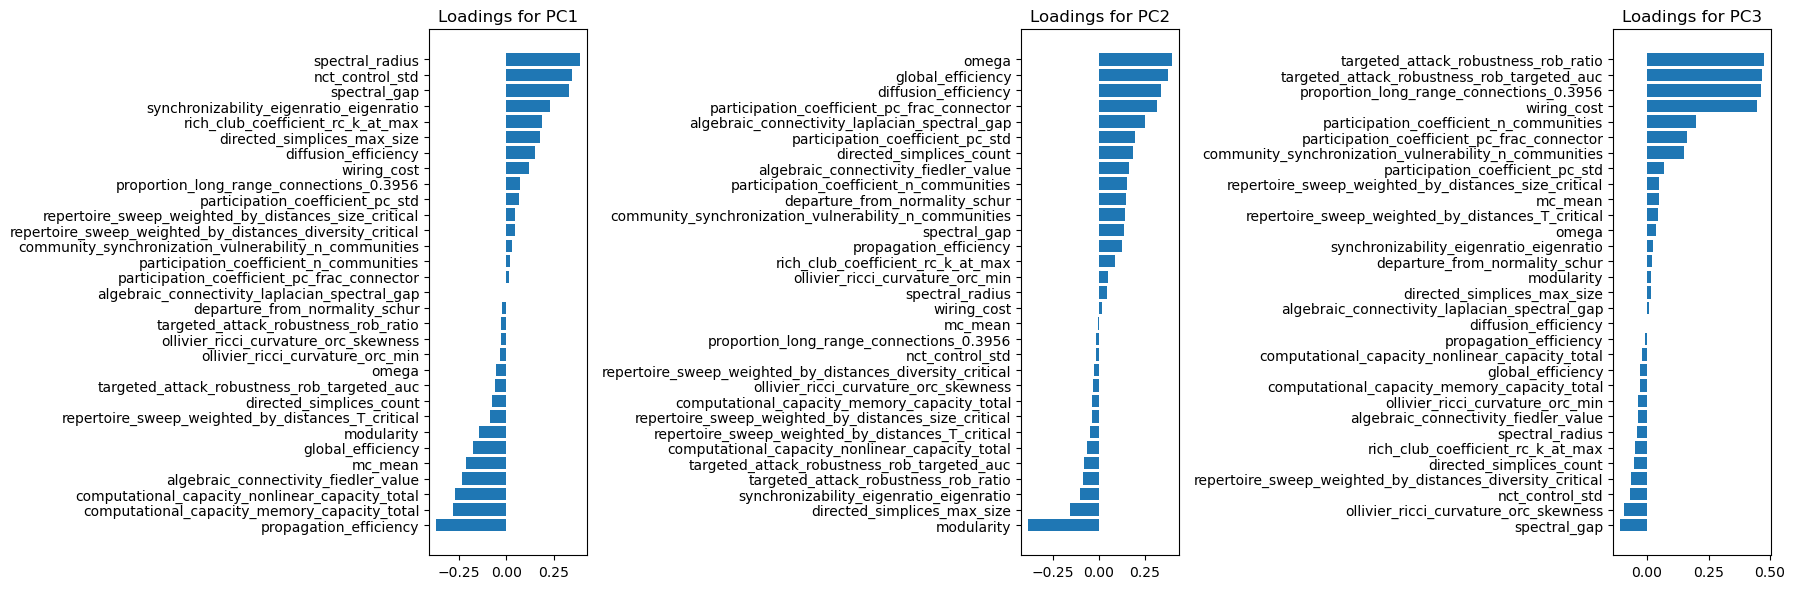

In [182]:

# Subplots of loadings for the first 3 principal components, ONLY top 10 contributors
loadings = pca.components_.T[:, :]
num_metrics = loadings.shape[0]
metric_names = huge_df_properties.columns


fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18,6), dpi=100)
for i in range(3):
    
    # order them all by the absolute value of their loading on the first principal component
    sorted_indices = np.argsort((loadings[:, i])) # [::-1]
    loadings = loadings[sorted_indices]
    metric_names = metric_names[sorted_indices]


    axs[i].barh(range(num_metrics), loadings[:, i])
    axs[i].set_yticks(range(num_metrics))
    axs[i].set_yticklabels(metric_names, rotation=0)
    axs[i].set_title(f"Loadings for PC{i+1}")
plt.tight_layout()
plt.show()


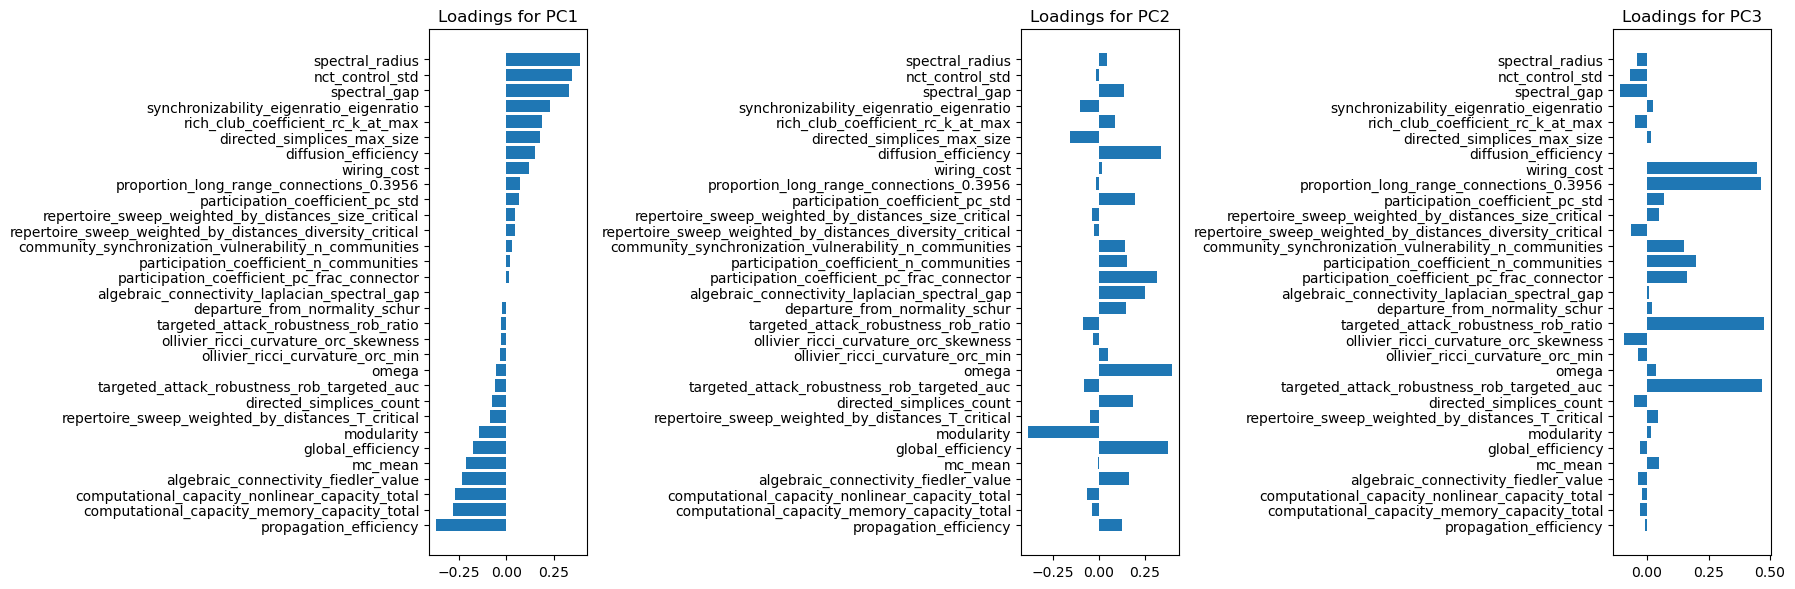

In [183]:

# Subplots of loadings for the first 3 principal components, ONLY top 10 contributors
loadings = pca.components_.T[:, :]
num_metrics = loadings.shape[0]
metric_names = huge_df_properties.columns

# order them all by the absolute value of their loading on the first principal component
sorted_indices = np.argsort((loadings[:, 0])) # [::-1]
loadings = loadings[sorted_indices]
metric_names = metric_names[sorted_indices]

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18,6), dpi=100)
for i in range(3):
    axs[i].barh(range(num_metrics), loadings[:, i])
    axs[i].set_yticks(range(num_metrics))
    axs[i].set_yticklabels(metric_names, rotation=0)
    axs[i].set_title(f"Loadings for PC{i+1}")
plt.tight_layout()
plt.show()


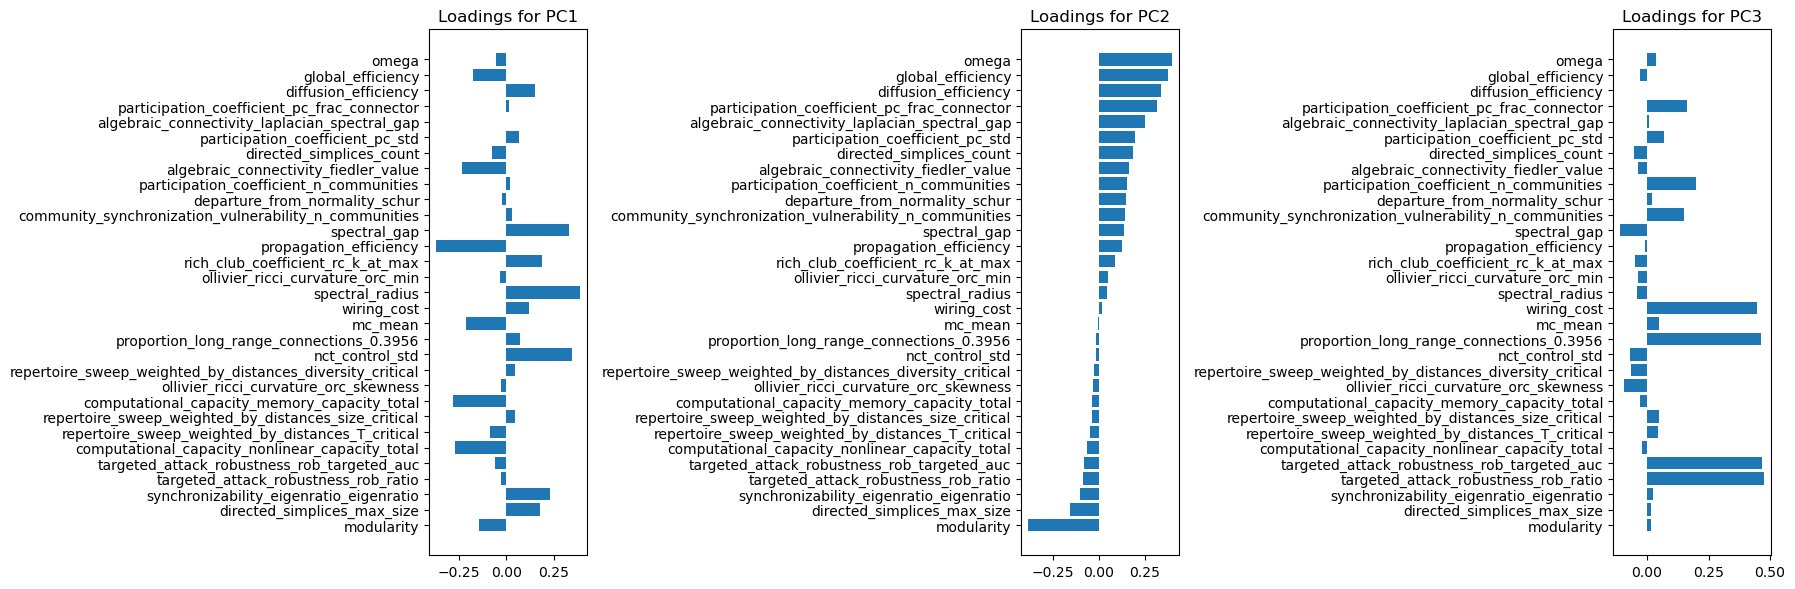

In [184]:

# Subplots of loadings for the first 3 principal components, ONLY top 10 contributors
loadings = pca.components_.T[:, :]
num_metrics = loadings.shape[0]
metric_names = huge_df_properties.columns

# order them all by the absolute value of their loading on the first principal component
sorted_indices = np.argsort((loadings[:, 1])) # [::-1]
loadings = loadings[sorted_indices]
metric_names = metric_names[sorted_indices]

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18,6), dpi=100)
for i in range(3):
    axs[i].barh(range(num_metrics), loadings[:, i])
    axs[i].set_yticks(range(num_metrics))
    axs[i].set_yticklabels(metric_names, rotation=0)
    axs[i].set_title(f"Loadings for PC{i+1}")
plt.tight_layout()
plt.show()


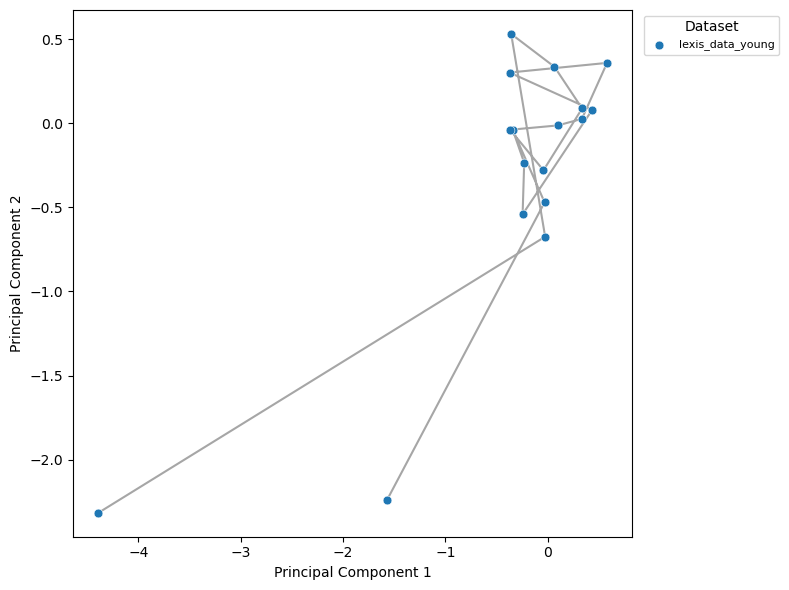

In [185]:
# ── 3. Average PC scores per dataset × age ───────────────────────────────────
pca_df = pd.DataFrame(pca_result[:, :2], columns=["PC1", "PC2"])
pca_df["age"]     = huge_df["age"].values
pca_df["dataset"] = huge_df["dataset"].values

dataset_age_means = (
    pca_df.groupby(["dataset", "age"])[["PC1", "PC2"]]
    .mean()
    .reset_index()
    .sort_values(["dataset", "age"])
)

# ── 4. Plot ───────────────────────────────────────────────────────────────────
datasets  = dataset_age_means["dataset"].unique()
palette   = dict(zip(datasets, plt.cm.tab10.colors))

fig, ax = plt.subplots(figsize=(8, 6))

for ds, grp in dataset_age_means.groupby("dataset"):
    colour = palette[ds]
    age_vals = grp["age"].values
    t = np.linspace(age_vals.min(), age_vals.max(), 300)

    spl_pc1 = make_smoothing_spline(age_vals, grp["PC1"].values, lam=5)
    spl_pc2 = make_smoothing_spline(age_vals, grp["PC2"].values, lam=5)

    ax.plot(grp["PC1"].values, 
            grp["PC2"].values, # spl_pc1(t), spl_pc2(t), 
            color="gray", linewidth=1.5, alpha=0.7, zorder=1)
    # Line through the age-averaged points (sorted by age)
    # ax.plot(age_means["PC1"], age_means["PC2"],
    #         color="grey", linewidth=0.8, alpha=0.6, zorder=1)

    ax.scatter(grp["PC1"], grp["PC2"],
               color=colour, s=40, zorder=2,
               edgecolors="white", linewidths=0.4, label=ds)

ax.legend(title="Dataset", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
# ax.set_title("PCA of Metrics — averaged per dataset × age")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

Dropped columns: []


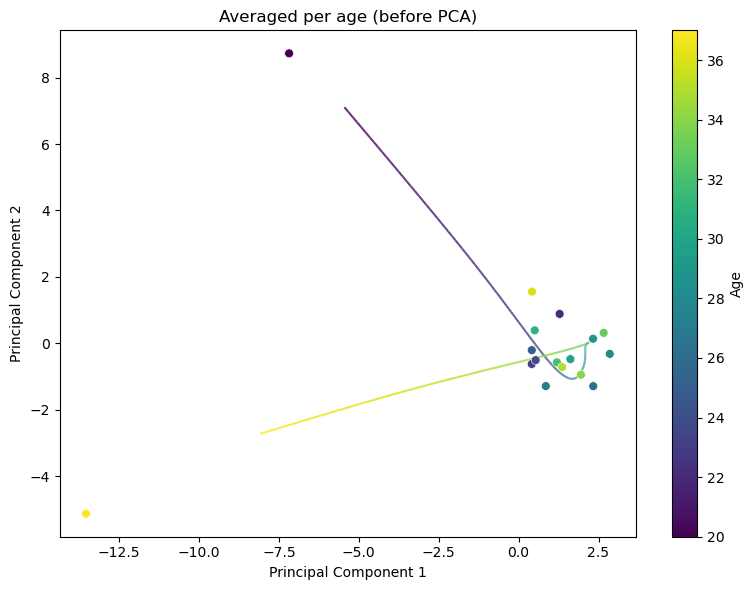

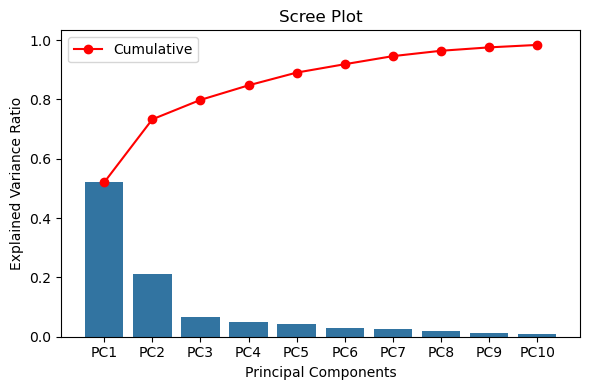

In [186]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.interpolate import make_smoothing_spline
from matplotlib.collections import LineCollection

# ── 1. Clean ──────────────────────────────────────────────────────────────────
dropped_cols = huge_df_properties.columns[huge_df_properties.isnull().any()].tolist()
huge_df_properties.replace([np.inf, -np.inf], np.nan, inplace=True)
huge_df_properties.dropna(axis=1, inplace=True)
print(f"Dropped columns: {dropped_cols}")

# ── 2. Average over all networks of the same age FIRST ───────────────────────
props_with_age = huge_df_properties.copy()
props_with_age["age"] = huge_df["age"].values
age_means_raw = props_with_age.groupby("age").mean().reset_index().sort_values("age")

age_vals    = age_means_raw["age"].values
feature_mat = age_means_raw.drop(columns="age").values

# ── 3. Scale & PCA on the age-averaged data ───────────────────────────────────
scaler = StandardScaler()
scaled = scaler.fit_transform(feature_mat)

pca = PCA(n_components=min(10, scaled.shape[0]))
pca_result = pca.fit_transform(scaled)

age_means = pd.DataFrame({
    "age": age_vals,
    "PC1": pca_result[:, 0],
    "PC2": pca_result[:, 1],
})

# ── 4. Smooth spline through age-ordered PC scores ───────────────────────────
t = np.linspace(age_vals.min(), age_vals.max(), 300)
smooth_pc1 = make_smoothing_spline(age_vals, age_means["PC1"].values, lam=5)(t)
smooth_pc2 = make_smoothing_spline(age_vals, age_means["PC2"].values, lam=5)(t)

# ── 5. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

norm = plt.Normalize(age_vals.min(), age_vals.max())
cmap = plt.cm.viridis

# Smoothed trajectory coloured by age
points   = np.array([smooth_pc1, smooth_pc2]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=1.5, alpha=0.8, zorder=1)
lc.set_array(t)
ax.add_collection(lc)

# One dot per age
sc = ax.scatter(age_means["PC1"], age_means["PC2"],
                c=age_means["age"], 
                cmap=cmap, norm=norm,
                s=40, zorder=2, edgecolors="white", linewidths=0.4)

ax.autoscale()
fig.colorbar(sc, ax=ax, label="Age")
ax.set_title("Averaged per age (before PCA)")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

# ── 6. Scree plot ─────────────────────────────────────────────────────────────
explained_variance = pca.explained_variance_ratio_
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=[f"PC{i+1}" for i in range(len(explained_variance))],
            y=explained_variance, ax=ax)
ax.plot(range(len(explained_variance)), np.cumsum(explained_variance),
        marker="o", color="red", label="Cumulative")
ax.set_title("Scree Plot")
ax.set_ylabel("Explained Variance Ratio")
ax.set_xlabel("Principal Components")
ax.legend()
plt.tight_layout()
plt.show()

In [187]:
# ── Proper biplot vectors: loading × √eigenvalue ─────────────────────────────
# pca.components_ shape: (n_components, n_features)
# pca.explained_variance_ shape: (n_components,)

scale = np.sqrt(pca.explained_variance_[:2])  # [√λ1, √λ2]

loadings = pd.DataFrame(
    (pca.components_[:2] * scale[:, None]).T,  # scale each PC axis
    index=huge_df_properties.columns,
    columns=["PC1", "PC2"]
)

In [188]:
# # Look at huge_df where age is defined. Then plot the pca space colored by age.
# huge_df_age = huge_df[huge_df["age"].notna()]
# plt.figure(figsize=(6,5))
# plt.scatter(pca_result[huge_df["age"].notna(), 0], 
#             pca_result[huge_df["age"].notna(), 1],
#             c=huge_df_age["age"], 
#             cmap="hot", # viridis", 
#             s=5, 
#             alpha=0.4) # s=20, edgecolors="none")
# plt.colorbar(label="Age")
# plt.xlabel("PC1")
# plt.ylabel("PC2")
# plt.title("PCA colored by age (only datasets with age info)")
# plt.tight_layout()


In [189]:
# # Look at huge_df where age is defined. Then plot the pca space colored by age.
# huge_df_age = huge_df[huge_df["age"].notna()]
# plt.figure(figsize=(6,5))
# plt.scatter(sel_pca_result[huge_df["age"].notna(), 0], sel_pca_result[huge_df["age"].notna(), 1],
#             c=huge_df["age"], # [huge_df_age["age"].loc[i] for i in huge_df["age"].notna() if huge_df_age["age"].loc[i] != -1 else 0], 
#             cmap="hot", # viridis", 
#             s=5, 
#             alpha=0.4) # s=20, edgecolors="none")
# plt.colorbar(label="Age")
# plt.xlabel("PC1")
# plt.ylabel("PC2")
# plt.title("PCA colored by age (only datasets with age info)")
# plt.tight_layout()


In [190]:
pca_result.shape

(17, 10)

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_58056/395287171.py:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(pca_result[:, 0],


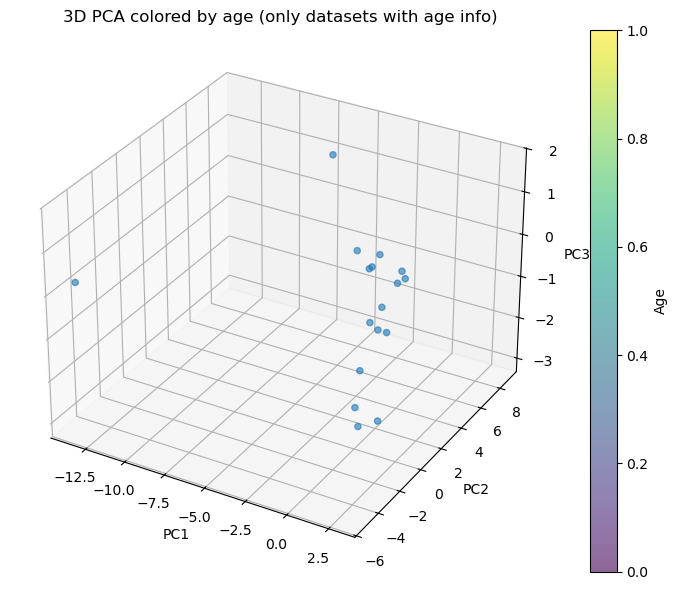

In [191]:
# Now in 3D: Look at huge_df where age is defined. Then plot the pca space colored by age. Make it interactive. 
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(pca_result[:, 0], 
                     pca_result[:, 1], 
                     pca_result[:, 2],
                    #  c=huge_df_age["age"], 
                     cmap="hot",
                     s=20,
                     alpha=0.6)
fig.colorbar(scatter, label="Age")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA colored by age (only datasets with age info)")
plt.tight_layout()
plt.show()

NameError: name 'sel_pca_result' is not defined

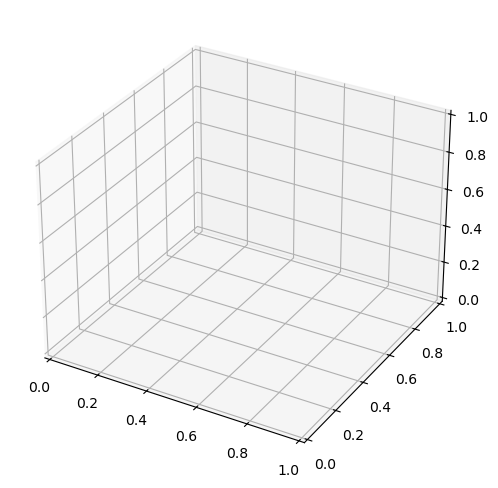

In [192]:
# Now in 3D: Look at huge_df where age is defined. Then plot the pca space colored by age. Make it interactive. 
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(sel_pca_result[:, 0], 
                     sel_pca_result[:, 1], 
                     sel_pca_result[:, 2],
                     c=huge_df["age"], 
                     cmap="hot",
                     s=20,
                     alpha=0.6)
fig.colorbar(scatter, label="Age")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA colored by age (only datasets with age info)")
plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px
import pandas as pd

plot_df = pd.DataFrame({
    'PC1': sel_pca_result[:, 0],
    'PC2': sel_pca_result[:, 1],
    'PC3': sel_pca_result[:, 2],
    'age': huge_df["age"].values
})

fig = px.scatter_3d(
    plot_df, x='PC1', y='PC2', z='PC3',
    color='age',
    color_continuous_scale='hot',
    opacity=0.6,
    size_max=10,
    title='3D PCA colored by age (only datasets with age info)'
)
fig.update_traces(marker=dict(size=3))
fig.show()

/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


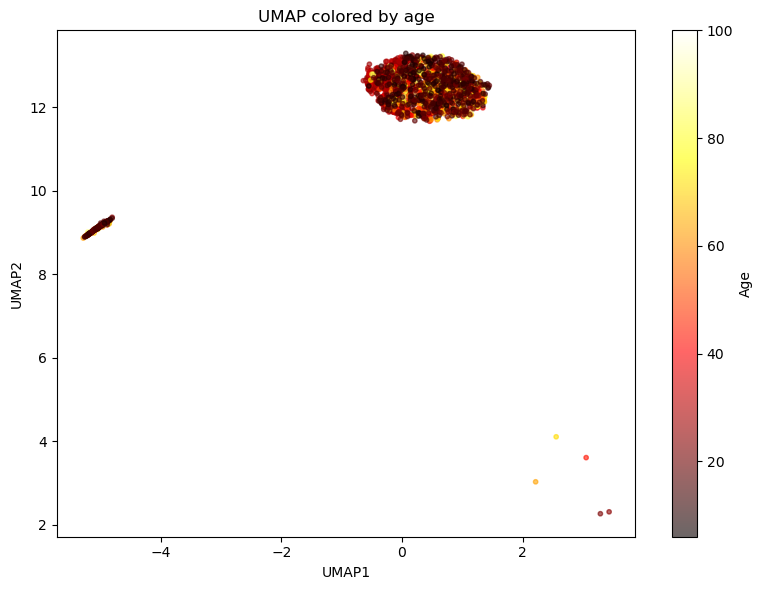

In [ ]:
import umap
import matplotlib.pyplot as plt
import numpy as np

# Fit UMAP on all data, then visualize age-labeled subset
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)

# Fit on the full dataset (or just age subset — your choice, see note below)
age_mask = huge_df["age"].notna()
embedding = reducer.fit_transform(sel_pca_result)  # use PCA result as input

# Plot only age-labeled points
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    # embedding[:, 0],
    # embedding[:, 1],
    embedding[age_mask, 0],
    embedding[age_mask, 1],
    c=huge_df_age["age"],
    cmap="hot",
    s=10,
    alpha=0.6
)
plt.colorbar(sc, label="Age")
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("UMAP colored by age")
plt.tight_layout()
plt.show()

/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



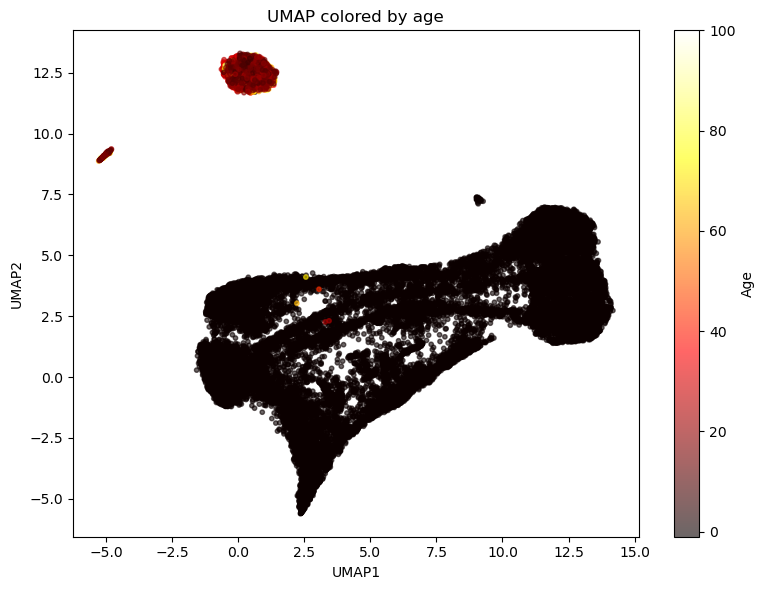

In [ ]:
import umap
import matplotlib.pyplot as plt
import numpy as np

# Fit UMAP on all data, then visualize age-labeled subset
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)

# Fit on the full dataset (or just age subset — your choice, see note below)
embedding = reducer.fit_transform(sel_pca_result)  # use PCA result as input

# Plot only age-labeled points
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=huge_df_age["age"],
    cmap="hot",
    s=10,
    alpha=0.6
)
plt.colorbar(sc, label="Age")
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("UMAP colored by age")
plt.tight_layout()
plt.show()

In [ ]:
# PHATE is actually purpose-built for continuous gradients
import phate
phate_op = phate.PHATE(n_components=2, random_state=42)
embedding_phate = phate_op.fit_transform(sel_pca_result[age_mask])

Calculating PHATE...
  Running PHATE on 2019 observations and 10 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.03 seconds.
    Calculating affinities...
    Calculated affinities in 0.36 seconds.
  Calculated graph and diffusion operator in 0.40 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 0.06 seconds.
    Calculating KMeans...
    Calculated KMeans in 0.77 seconds.
  Calculated landmark operator in 0.84 seconds.
  Calculating optimal t...
    Automatically selected t = 24
  Calculated optimal t in 0.27 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.08 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 0.97 seconds.
Calculated PHATE in 2.69 seconds.


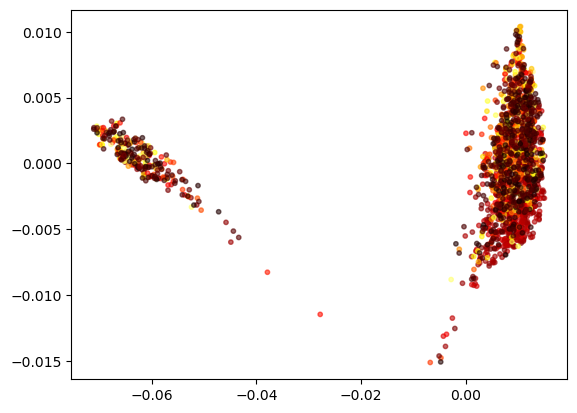

In [ ]:
plt.scatter(embedding_phate[:, 0], embedding_phate[:, 1], c=huge_df_age["age"], cmap="hot", s=10, alpha=0.6)

In [ ]:
age_mask

0        False
1        False
2        False
3        False
4        False
         ...  
27241     True
27242     True
27243    False
27244    False
27245    False
Name: age, Length: 27246, dtype: bool

In [ ]:
# Which datasets are in that isolated cluster?
from sklearn.cluster import DBSCAN

clusters = DBSCAN(eps=0.5, min_samples=5).fit_predict(embedding)
# print(huge_df_age[age_mask].groupby(clusters)["dataset"].value_counts())  # or species/source column

In [ ]:
clusters

array([0, 0, 0, ..., 0, 0, 0], shape=(27246,))

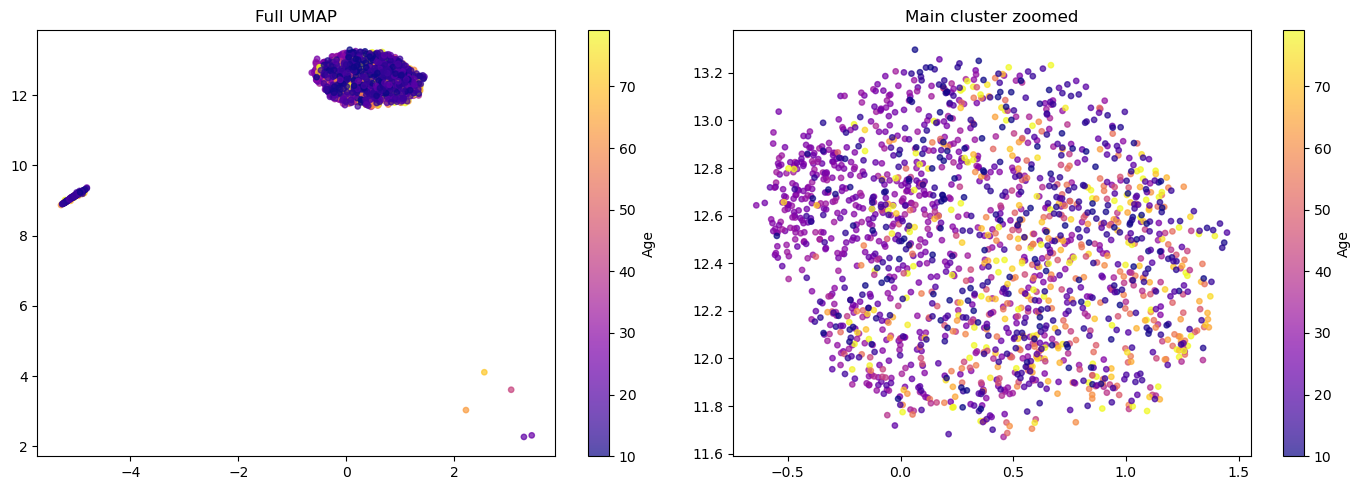

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full view
# Right: zoomed to main cluster
main = (embedding[:, 0] > -2) & (embedding[:, 1] > 10)  # adjust to your blob

for ax, mask in zip(axes, [age_mask, age_mask & main]):
    sc = ax.scatter(embedding[mask, 0], embedding[mask, 1],
                    c=huge_df_age["age"][mask],  # adjust indexing
                    cmap="plasma",   # better perceptual uniformity than "hot"
                    s=15, alpha=0.7,
                    vmin=np.percentile(huge_df_age["age"], 5),   # clip outliers
                    vmax=np.percentile(huge_df_age["age"], 95))
    plt.colorbar(sc, ax=ax, label="Age")

axes[0].set_title("Full UMAP")
axes[1].set_title("Main cluster zoomed")
plt.tight_layout()
plt.show()

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_91278/808219703.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ax, (label, grp) in zip(axes, huge_df_age.assign(bin=age_bins).groupby("bin")):


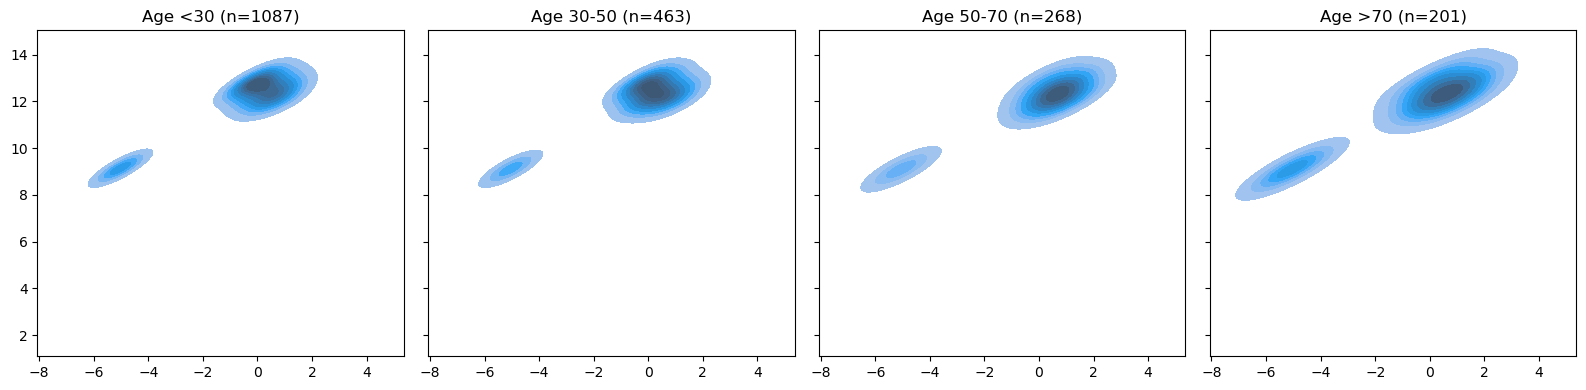

In [ ]:
import seaborn as sns

age_bins = pd.cut(huge_df_age["age"], bins=[0, 30, 50, 70, 100], 
                  labels=["<30", "30-50", "50-70", ">70"])

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)
for ax, (label, grp) in zip(axes, huge_df_age.assign(bin=age_bins).groupby("bin")):
    idx = grp.index  # make sure this aligns with embedding rows
    sns.kdeplot(x=embedding[idx, 0], y=embedding[idx, 1], ax=ax, fill=True)
    ax.set_title(f"Age {label} (n={len(grp)})")
plt.tight_layout()

In [ ]:
from sklearn.metrics import pairwise_distances
from scipy.stats import f_oneway
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.utils import shuffle


X = pca_result[huge_df["age"].notna()][:, :2]  # PC1 + PC2 only
labels = sel_df_label[huge_df["age"].notna()]["dataset"].values

# # ── Extract the relevant PCA coordinates + labels ─────────────────────────────

# mami_mask  = (sel_df_label["dataset"] == "suarez_MaMI_dataset").values
# tax_mask   = df_mami[taxonomy].isin(GROUPS_TO_INCLUDE).values
# combined   = mami_mask.copy()
# combined[mami_mask] = tax_mask          # both conditions

# X      = sel_pca_result[combined, :2]   # PC1 + PC2 only
# labels = df_mami[tax_mask][taxonomy].values

# # ── Test 1: PERMANOVA (permutation-based MANOVA on distances) ─────────────────
# # "Are the groups more separated than random chance?"

# from sklearn.utils import shuffle

def permanova(X, labels, n_permutations=999):
    def f_stat(X, labels):
        groups  = [X[labels == g] for g in np.unique(labels)]
        grand_m = X.mean(axis=0)
        ss_between = sum(len(g) * ((g.mean(0) - grand_m)**2).sum() for g in groups)
        ss_within  = sum(((g - g.mean(0))**2).sum() for g in groups)
        k, n = len(groups), len(X)
        return (ss_between / (k-1)) / (ss_within / (n-k))

    observed = f_stat(X, labels)
    null_dist = [f_stat(X, shuffle(labels)) for _ in range(n_permutations)]
    p = (np.sum(np.array(null_dist) >= observed) + 1) / (n_permutations + 1)
    return observed, p

f_obs, p_perm = permanova(X, labels)
print(f"PERMANOVA  →  F = {f_obs:.3f},  p = {p_perm:.4f}")

# ── Test 2: Per-axis ANOVA ─────────────────────────────────────────────────────
# "Does any single PC axis separate the groups?"

groups_pc1 = [X[labels == g, 0] for g in np.unique(labels)]
groups_pc2 = [X[labels == g, 1] for g in np.unique(labels)]
f1, p1 = f_oneway(*groups_pc1)
f2, p2 = f_oneway(*groups_pc2)
print(f"ANOVA PC1  →  F = {f1:.3f},  p = {p1:.4f}")
print(f"ANOVA PC2  →  F = {f2:.3f},  p = {p2:.4f}")

# ── Test 3: LDA cross-validated accuracy ──────────────────────────────────────
# "Can we predict group membership better than chance?"

from sklearn.model_selection import cross_val_score
lda      = LinearDiscriminantAnalysis()
cv_score = cross_val_score(lda, X, labels, cv=5, scoring="accuracy").mean()
chance   = 1 / len(np.unique(labels))
print(f"LDA 5-fold CV accuracy = {cv_score:.3f}  (chance = {chance:.3f})")

PERMANOVA  →  F = 293.763,  p = 0.0010
ANOVA PC1  →  F = 267.967,  p = 0.0000
ANOVA PC2  →  F = 333.227,  p = 0.0000
LDA 5-fold CV accuracy = 0.553  (chance = 0.333)


ValueError: 'c' argument has 2019 elements, which is inconsistent with 'x' and 'y' with size 27246.

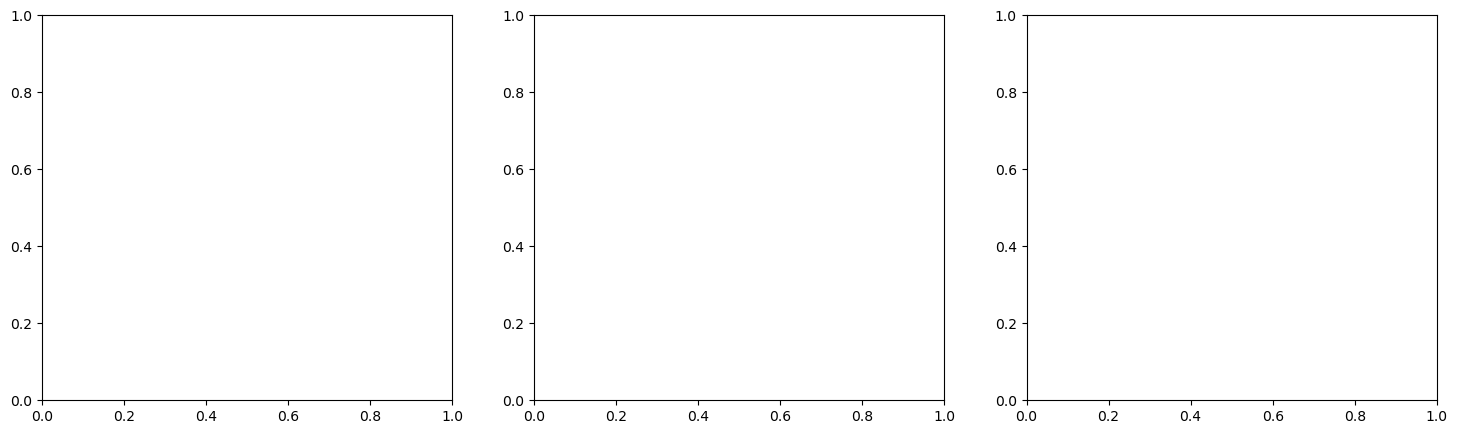

In [ ]:
from sklearn.manifold import TSNE
from sklearn.decomposition import KernelPCA
import matplotlib.pyplot as plt
import numpy as np

age_mask = huge_df["age"].notna()
X = huge_df[age_mask].drop(columns=["dataset", "age"]) #  sel_pca_result[age_mask]  # using PCA result as input (50 components recommended)
ages = huge_df_age["age"].values

# ── 1. t-SNE ──────────────────────────────────────────────────────────────────
# Try multiple perplexity values — this is the key hyperparameter
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, perp in zip(axes, [15, 30, 50]):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42) # , n_iter=1000)
    emb = tsne.fit_transform(X)
    sc = ax.scatter(emb[:, 0], emb[:, 1],
                    c=ages, # ages,
                    cmap="plasma", s=10, alpha=0.6,
                    vmin=np.percentile(ages, 5),
                    vmax=np.percentile(ages, 95))
    plt.colorbar(sc, ax=ax, label="Age")
    ax.set_title(f"t-SNE (perplexity={perp})")
    ax.set_xlabel("tSNE1")
    ax.set_ylabel("tSNE2")

plt.suptitle("t-SNE colored by age", y=1.02)
plt.tight_layout()
plt.show()

# ── 2. Kernel PCA ─────────────────────────────────────────────────────────────
# Try rbf (non-linear) vs linear (should match regular PCA) vs poly
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, kernel in zip(axes, ["rbf", "poly", "cosine"]):
    kpca = KernelPCA(n_components=2, kernel=kernel, random_state=42)
    emb = kpca.fit_transform(X)
    sc = ax.scatter(emb[:, 0], emb[:, 1],
                    c=ages, cmap="plasma", s=10, alpha=0.6,
                    vmin=np.percentile(ages, 5),
                    vmax=np.percentile(ages, 95))
    plt.colorbar(sc, ax=ax, label="Age")
    ax.set_title(f"Kernel PCA ({kernel})")
    ax.set_xlabel("KPC1")
    ax.set_ylabel("KPC2")

plt.suptitle("Kernel PCA colored by age", y=1.02)
plt.tight_layout()
plt.show()

# ── 3. Quantify: can Kernel PCA components predict age? ───────────────────────
# This is the key advantage of KernelPCA over UMAP/tSNE — you CAN regress on it
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

results = {}
for kernel in ["linear", "rbf", "poly", "cosine"]:
    kpca = KernelPCA(n_components=10, kernel=kernel, random_state=42)
    X_kpca = kpca.fit_transform(X)
    cv_r2 = cross_val_score(LinearRegression(), X_kpca, ages, cv=5, scoring="r2")
    results[kernel] = (cv_r2.mean(), cv_r2.std())
    print(f"Kernel={kernel:8s} | CV R² = {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")

In [ ]:
age_mask = huge_df["age"] != -1
age_mask

0        False
1        False
2        False
3        False
4        False
         ...  
27241     True
27242     True
27243    False
27244    False
27245    False
Name: age, Length: 27246, dtype: bool

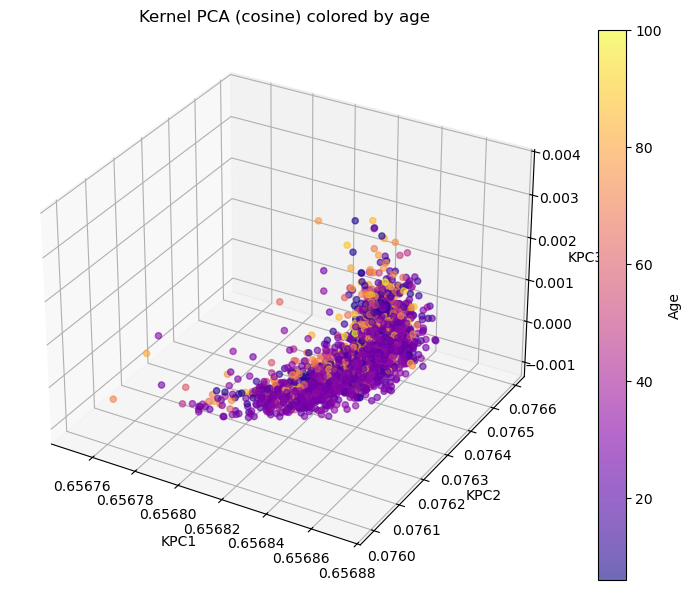

In [ ]:
# 3D plot of KPCA (cosine) colored by age
from mpl_toolkits.mplot3d import Axes3D
kpca = KernelPCA(n_components=3, kernel="cosine", random_state=42)
X_kpca = kpca.fit_transform(X)
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

age_mask = huge_df["age"] != -1

scatter = ax.scatter(X_kpca[age_mask][:, 0], 
                     X_kpca[age_mask][:, 1], 
                     X_kpca[age_mask][:, 2],
                     c=ages, 
                     cmap="plasma",
                     s=20, alpha=0.6)
fig.colorbar(scatter, label="Age")
ax.set_xlabel("KPC1")
ax.set_ylabel("KPC2")
ax.set_zlabel("KPC3")
ax.set_title("Kernel PCA (cosine) colored by age")
plt.tight_layout()
plt.show()

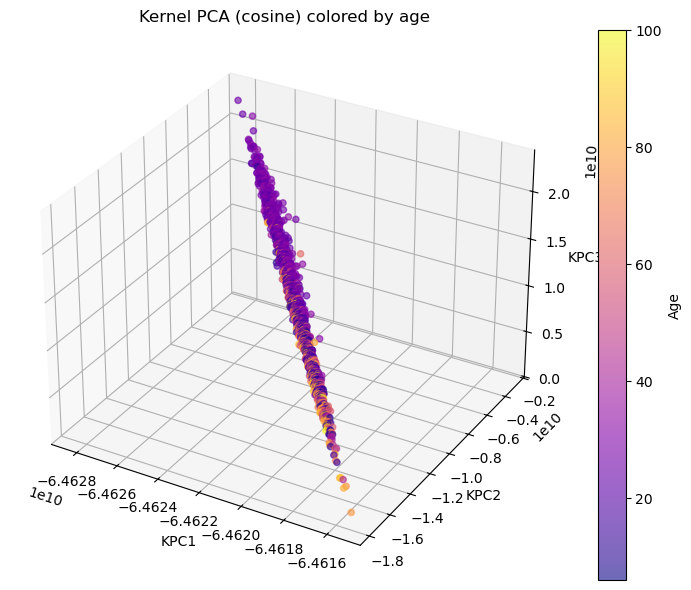

In [ ]:
# 3D plot of KPCA (poly) colored by age
from mpl_toolkits.mplot3d import Axes3D
kpca = KernelPCA(n_components=3, kernel="poly", random_state=42)
X_kpca = kpca.fit_transform(X)
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

age_mask = huge_df["age"] != -1

scatter = ax.scatter(X_kpca[age_mask][:, 0], 
                     X_kpca[age_mask][:, 1], 
                     X_kpca[age_mask][:, 2],
                     c=ages, 
                     cmap="plasma",
                     s=20, alpha=0.6)
fig.colorbar(scatter, label="Age")
ax.set_xlabel("KPC1")
ax.set_ylabel("KPC2")
ax.set_zlabel("KPC3")
ax.set_title("Kernel PCA (cosine) colored by age")
plt.tight_layout()
plt.show()

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_91278/1339536815.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  c=pd.factorize(huge_df_age[age_mask]["dataset"])[0],


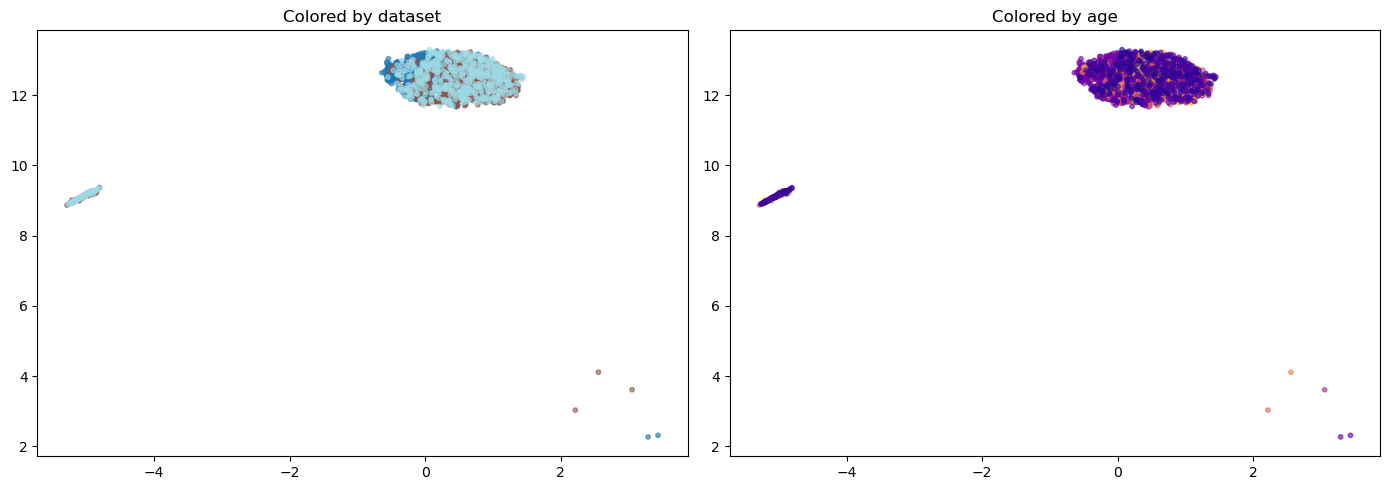

In [ ]:
# Color your existing UMAP/t-SNE by dataset instead of age
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: colored by dataset
sc1 = axes[0].scatter(embedding[age_mask, 0], embedding[age_mask, 1],
                       c=pd.factorize(huge_df_age[age_mask]["dataset"])[0],
                       cmap="tab20", s=10, alpha=0.6)
axes[0].set_title("Colored by dataset")

# Right: colored by age
sc2 = axes[1].scatter(embedding[age_mask, 0], 
                      embedding[age_mask, 1],
                       c=ages, # [age_mask], 
                       cmap="plasma", s=10, alpha=0.6)
axes[1].set_title("Colored by age")

plt.tight_layout()
plt.show()

In [ ]:
huge_df.keys()

Index(['transitivity', 'avg_clustering', 'modularity', 'degree_gini',
       'degree_assortativity', 'omega', 'structural_complexity',
       'directed_simplices_count', 'directed_simplices_max_size',
       'char_path_length', 'global_efficiency', 'diffusion_efficiency',
       'propagation_efficiency', 'avg_communicability',
       'topological_distance_mean', 'topological_distance_std',
       'avg_edge_distance', 'wiring_cost',
       'proportion_long_range_connections_0.1',
       'proportion_long_range_connections_0.3',
       'proportion_long_range_connections_0.3956',
       'proportion_long_range_connections_0.5', 'richclub_n_edges',
       'richclub_avg_length', 'rich_club_coefficient_rc_max_norm',
       'rich_club_coefficient_rc_mean_norm',
       'rich_club_coefficient_rc_k_at_max',
       'rich_club_coefficient_rc_regime_frac',
       'rich_club_coefficient_rc_weighted_auc', 'spectral_radius',
       'spectral_gap', 'synchronizability_eigenratio_eigenratio',
       'kerne

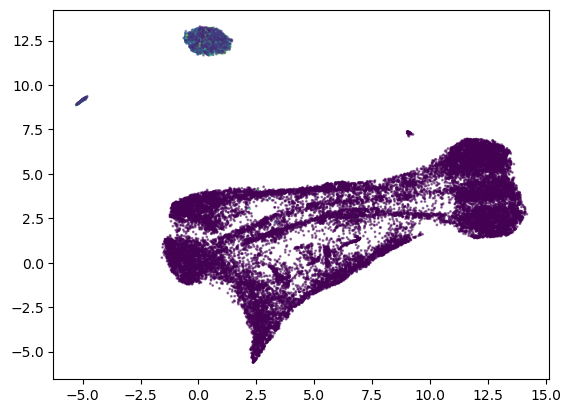

In [ ]:
plt.scatter(embedding[:,0], 
            embedding[:,1], 
            c=huge_df["age"].values,
            s=1, 
            alpha=0.5,
            )

(11.0, 14.0)

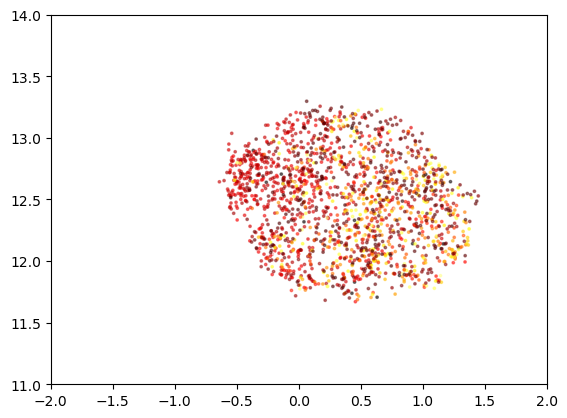

In [ ]:
plt.scatter(embedding[:,0], 
            embedding[:,1], 
            c=huge_df["age"].values,
            s=3, 
            alpha=0.5,
            cmap="hot",
            )

plt.xlim(-2, 2)
plt.ylim(11, 14)

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_91278/3966855115.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("tab20", len(unique_datasets))


Text(0.5, 1.0, 'UMAP colored by age and dataset')

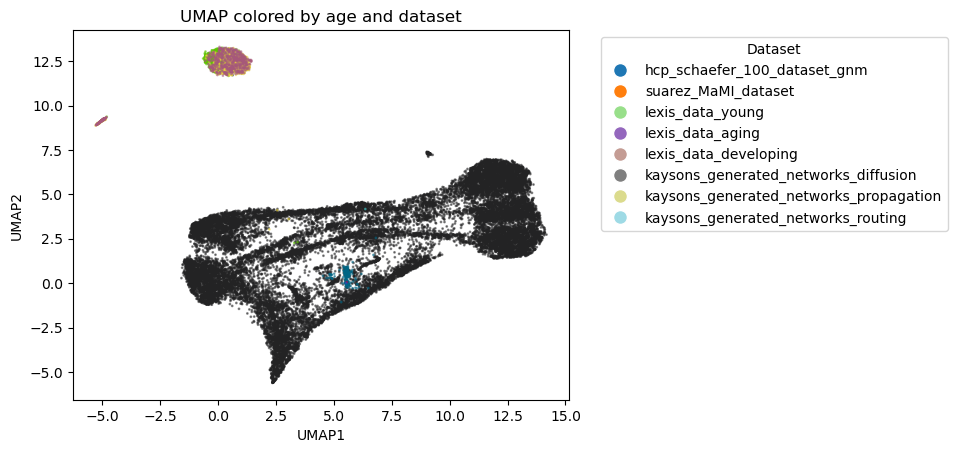

In [ ]:
colors_dataset = [COLOR_SCHEME[d] for d in huge_df["dataset"]]
colors_dataset = []

plt.scatter(embedding[:,0], 
            embedding[:,1], 
            c=colors_dataset,
            s=1, 
            alpha=0.5,
            )

# Add legend for datasets
unique_datasets = huge_df["dataset"].unique()
color_map = plt.cm.get_cmap("tab20", len(unique_datasets))
dataset_colors = {ds: color_map(i) for i, ds in enumerate(unique_datasets)}
plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', label=ds,
                              markerfacecolor=dataset_colors[ds], markersize=10)
                    for ds in unique_datasets],
           title="Dataset", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP colored by age and dataset")

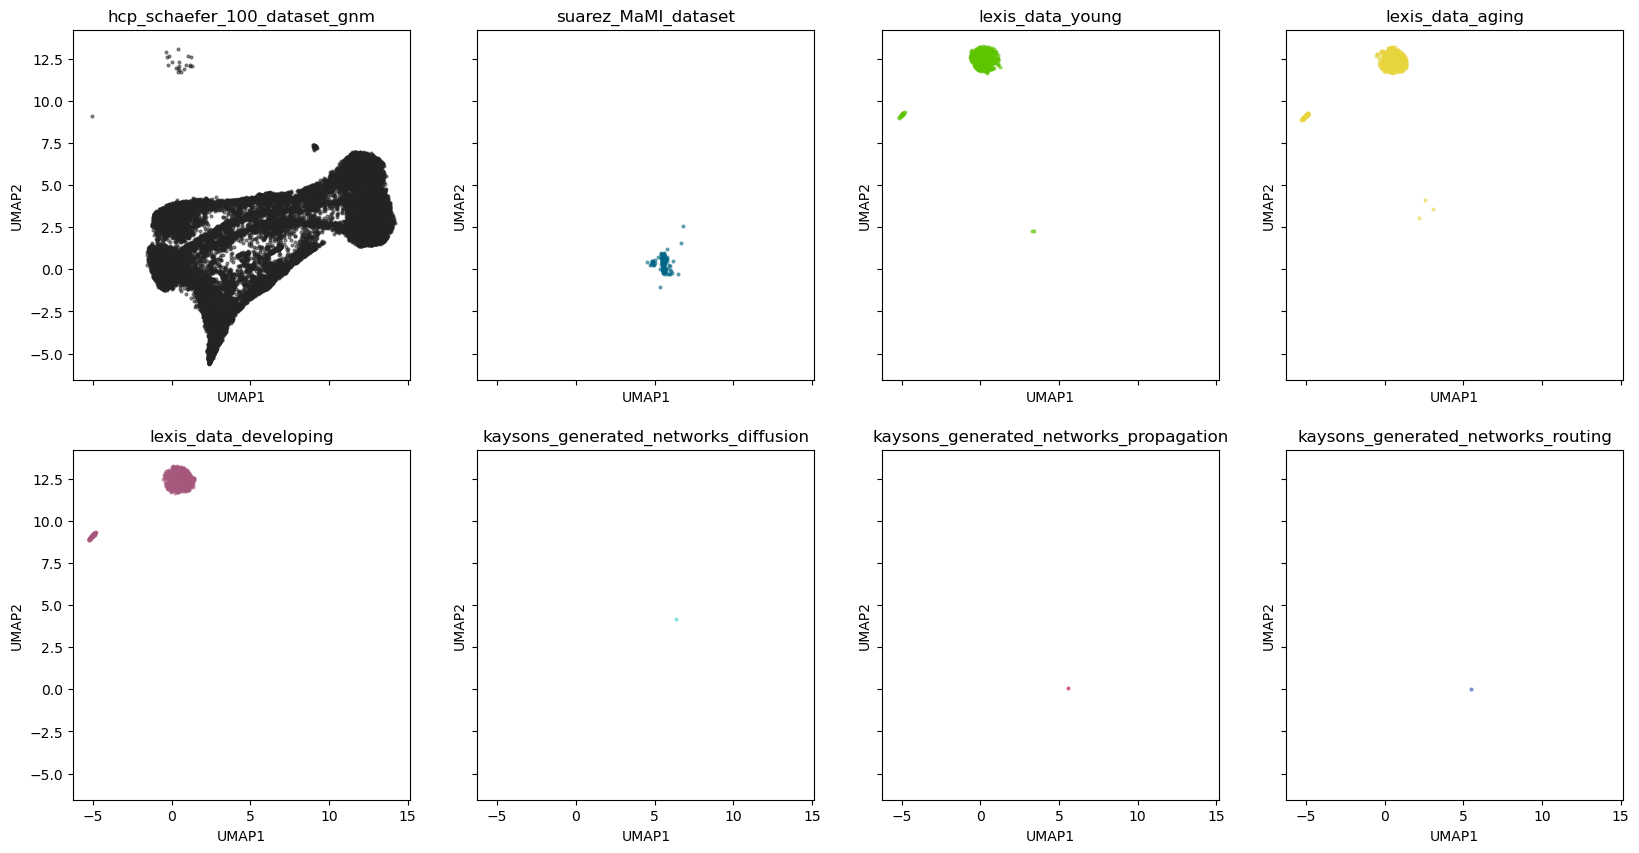

In [ ]:
# plot each dataset separately in a grid of subplots
unique_datasets = huge_df["dataset"].unique()
n = len(unique_datasets)
cols = 4
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, 5*rows), sharex=True, sharey=True)

for ax, dataset in zip(axes.flatten(), unique_datasets):
    mask = huge_df["dataset"] == dataset
    # convert to boolean array
    mask = mask.values.astype(bool)

    ax.scatter(embedding[mask, 0], 
               embedding[mask, 1], 
               c=COLOR_SCHEME[dataset], 
               s=4, #1
               alpha=0.5)
    
    ax.set_title(dataset)
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_91278/2596203960.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  for i, dataset in enumerate(huge_df_age[age_mask]["dataset"].unique()): # Left: colored by dataset
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_91278/2596203960.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  that_dataset_mask = (huge_df_age[age_mask]["dataset"] == dataset)


IndexError: boolean index did not match indexed array along axis 0; size of axis is 27246 but size of corresponding boolean axis is 2019

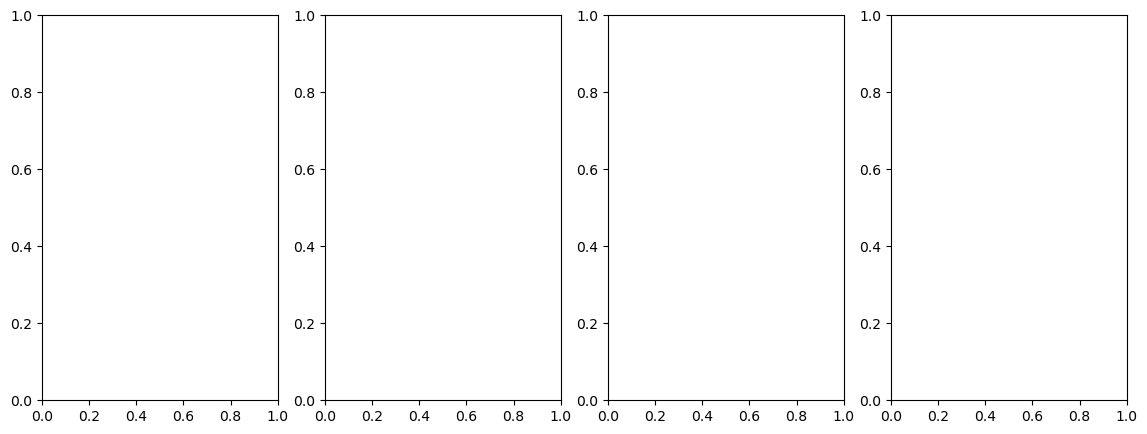

In [ ]:
fig, axs = plt.subplots(1, 4, figsize=(14, 5))

for i, dataset in enumerate(huge_df_age[age_mask]["dataset"].unique()): # Left: colored by dataset
    that_dataset_mask = (huge_df_age[age_mask]["dataset"] == dataset)
    sc1 = axs[i].scatter(embedding[that_dataset_mask, 0], 
                         embedding[that_dataset_mask, 1],
                        c=i, # pd.factorize(huge_df_age[that_dataset_mask][age_mask]["dataset"])[0],
                        cmap="tab20", s=10, alpha=0.6)
    axs[i].set_title("Colored by dataset")

In [ ]:
# Create a PCA between the columns of the huge_df
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(huge_df.drop("dataset", "age")) # _properties)

pca = PCA(n_components=10) # 10)
pca_result = pca.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(x=pca_result[:,0], 
            y=pca_result[:,1], 
            s=2, 
            alpha=0.4, 
            c=huge_df['color_dataset'], 
            # label=huge_df['dataset']
        )
plt.title("PCA of Metrics")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.show()

# Scree plot to show explained variance
explained_variance = pca.explained_variance_ratio_
plt.figure(figsize=(6,4))
sns.barplot(x=[f"PC{i+1}" for i in range(len(explained_variance))], y=explained_variance)
plt.plot(range(0, len(explained_variance)), np.cumsum(explained_variance), marker="o", color="red",
        label="Cumulative")
plt.title("Scree Plot")
plt.ylabel("Explained Variance Ratio")
plt.xlabel("Principal Components")
plt.tight_layout()
plt.show()

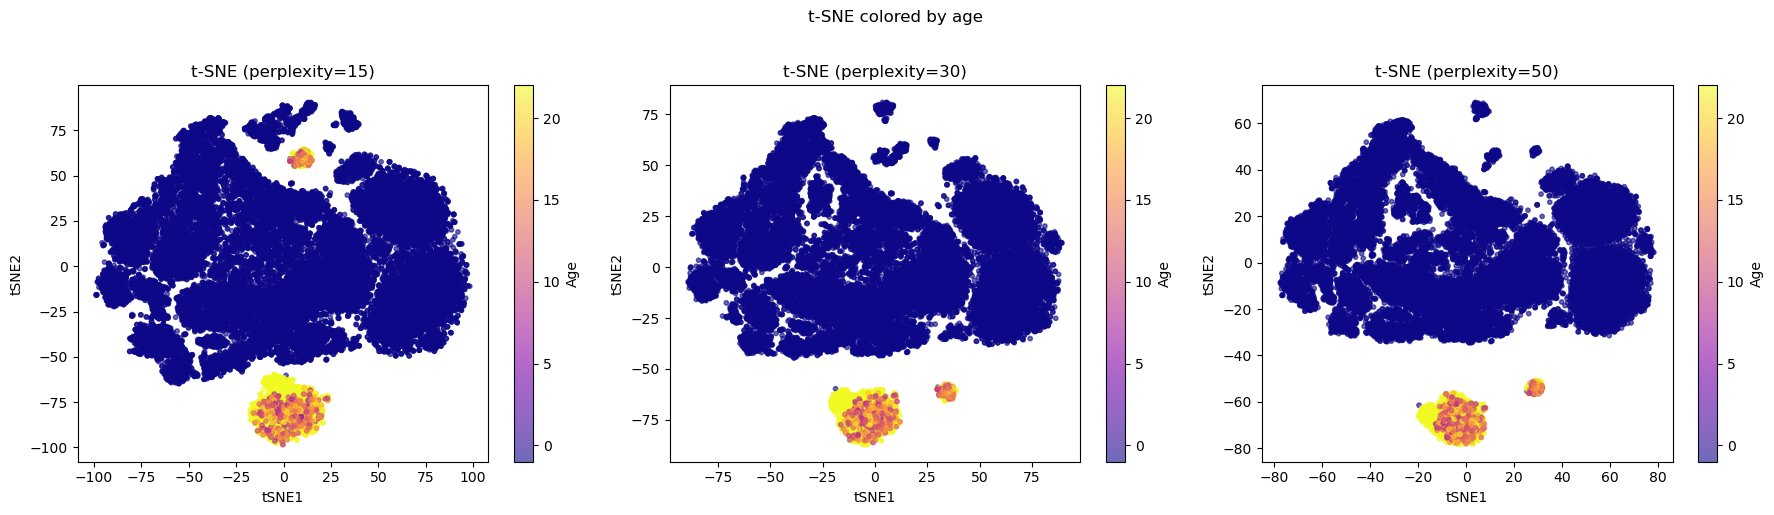

In [ ]:
from sklearn.manifold import TSNE
from sklearn.decomposition import KernelPCA
import matplotlib.pyplot as plt
import numpy as np

# age_mask = huge_df["age"].notna()
X = huge_df.drop(columns=["dataset", "age"]) #  sel_pca_result[age_mask]  # using PCA result as input (50 components recommended)

scaler = StandardScaler()
X = scaler.fit_transform(X)

# ages = huge_df_age["age"].values
ages_or_gray = huge_df["age"].values  # use age where available, else gray
ages_or_gray[huge_df["age"].isna()] = -1  # set missing ages to -1 for gray color
# ── 1. t-SNE ──────────────────────────────────────────────────────────────────
# Try multiple perplexity values — this is the key hyperparameter
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, perp in zip(axes, [15, 30, 50]):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42) # , n_iter=1000)
    emb = tsne.fit_transform(X)
    sc = ax.scatter(emb[:, 0], emb[:, 1],
                    c=ages_or_gray, cmap="plasma", s=10, alpha=0.6,
                    vmin=np.percentile(ages_or_gray, 5),
                    vmax=np.percentile(ages_or_gray, 95))
    plt.colorbar(sc, ax=ax, label="Age")
    ax.set_title(f"t-SNE (perplexity={perp})")
    ax.set_xlabel("tSNE1")
    ax.set_ylabel("tSNE2")

plt.suptitle("t-SNE colored by age", y=1.02)
plt.tight_layout()
plt.show()

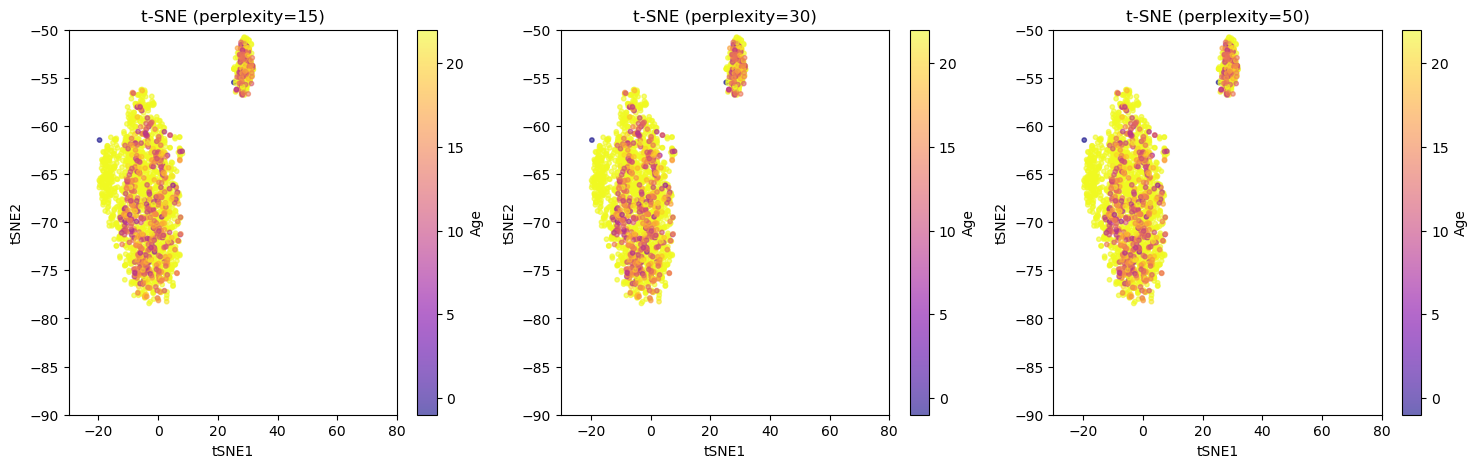

In [ ]:
# Try multiple perplexity values — this is the key hyperparameter
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, perp in zip(axes, [15, 30, 50]):
    # tsne = TSNE(n_components=2, perplexity=perp, random_state=42) # , n_iter=1000)
    # emb = tsne.fit_transform(X)
    sc = ax.scatter(emb[:, 0], emb[:, 1],
                    c=ages_or_gray, cmap="plasma", s=10, alpha=0.6,
                    vmin=np.percentile(ages_or_gray, 5),
                    vmax=np.percentile(ages_or_gray, 95))
    plt.colorbar(sc, ax=ax, label="Age")
    ax.set_xlim(-30, 80)
    ax.set_ylim(-90, -50)
    ax.set_title(f"t-SNE (perplexity={perp})")
    ax.set_xlabel("tSNE1")
    ax.set_ylabel("tSNE2")

ValueError: 'c' argument has 2019 elements, which is inconsistent with 'x' and 'y' with size 27246.

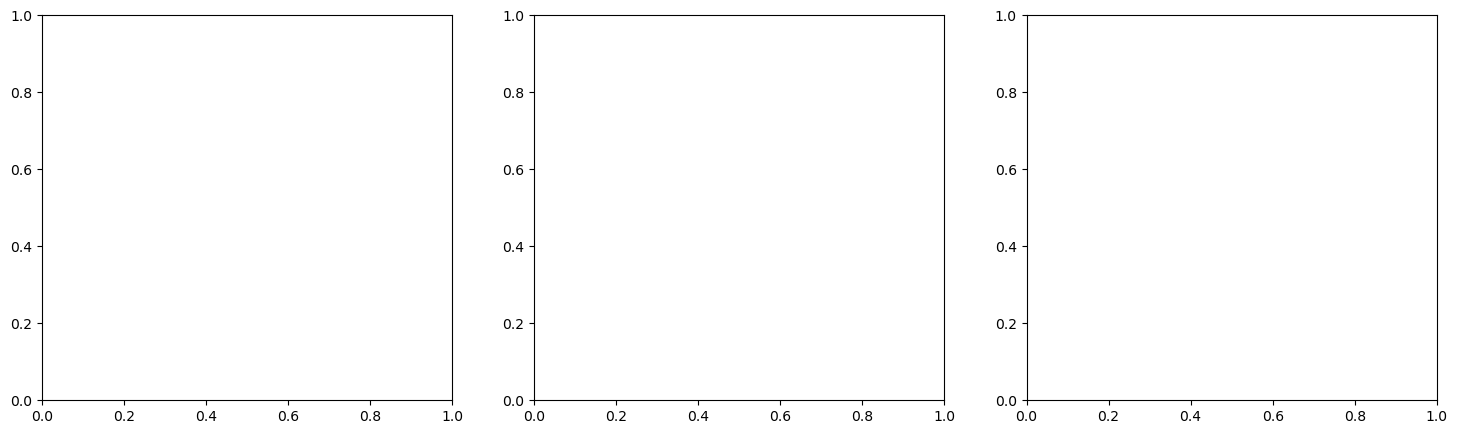

In [ ]:


# ── 2. Kernel PCA ─────────────────────────────────────────────────────────────
# Try rbf (non-linear) vs linear (should match regular PCA) vs poly
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, kernel in zip(axes, ["rbf", "poly", "cosine"]):
    kpca = KernelPCA(n_components=2, kernel=kernel, random_state=42)
    emb = kpca.fit_transform(X)
    sc = ax.scatter(emb[:, 0], emb[:, 1],
                    c=ages, cmap="plasma", s=10, alpha=0.6,
                    vmin=np.percentile(ages, 5),
                    vmax=np.percentile(ages, 95))
    plt.colorbar(sc, ax=ax, label="Age")
    ax.set_title(f"Kernel PCA ({kernel})")
    ax.set_xlabel("KPC1")
    ax.set_ylabel("KPC2")

plt.suptitle("Kernel PCA colored by age", y=1.02)
plt.tight_layout()
plt.show()

# ── 3. Quantify: can Kernel PCA components predict age? ───────────────────────
# This is the key advantage of KernelPCA over UMAP/tSNE — you CAN regress on it
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

results = {}
for kernel in ["linear", "rbf", "poly", "cosine"]:
    kpca = KernelPCA(n_components=10, kernel=kernel, random_state=42)
    X_kpca = kpca.fit_transform(X)
    cv_r2 = cross_val_score(LinearRegression(), X_kpca, ages, cv=5, scoring="r2")
    results[kernel] = (cv_r2.mean(), cv_r2.std())
    print(f"Kernel={kernel:8s} | CV R² = {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")

In [ ]:
from sklearn.manifold import TSNE
from sklearn.decomposition import KernelPCA
import matplotlib.pyplot as plt
import numpy as np

# age_mask = huge_df["age"].notna()
X = sel_pca_result # [age_mask]  # using PCA result as input (50 components recommended)
ages = huge_df_age["age"].values

# ── 1. t-SNE ──────────────────────────────────────────────────────────────────
# Try multiple perplexity values — this is the key hyperparameter
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, perp in zip(axes, [15, 30, 50]):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42) # , n_iter=1000)
    emb = tsne.fit_transform(X)
    sc = ax.scatter(emb[:, 0], emb[:, 1],
                    c=ages, cmap="plasma", s=10, alpha=0.6,
                    vmin=np.percentile(ages, 5),
                    vmax=np.percentile(ages, 95))
    plt.colorbar(sc, ax=ax, label="Age")
    ax.set_title(f"t-SNE (perplexity={perp})")
    ax.set_xlabel("tSNE1")
    ax.set_ylabel("tSNE2")

plt.suptitle("t-SNE colored by age", y=1.02)
plt.tight_layout()
plt.show()

# ── 2. Kernel PCA ─────────────────────────────────────────────────────────────
# Try rbf (non-linear) vs linear (should match regular PCA) vs poly
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, kernel in zip(axes, ["rbf", "poly", "cosine"]):
    kpca = KernelPCA(n_components=2, kernel=kernel, random_state=42)
    emb = kpca.fit_transform(X)
    sc = ax.scatter(emb[:, 0], emb[:, 1],
                    c=ages, cmap="plasma", s=10, alpha=0.6,
                    vmin=np.percentile(ages, 5),
                    vmax=np.percentile(ages, 95))
    plt.colorbar(sc, ax=ax, label="Age")
    ax.set_title(f"Kernel PCA ({kernel})")
    ax.set_xlabel("KPC1")
    ax.set_ylabel("KPC2")

plt.suptitle("Kernel PCA colored by age", y=1.02)
plt.tight_layout()
plt.show()

# ── 3. Quantify: can Kernel PCA components predict age? ───────────────────────
# This is the key advantage of KernelPCA over UMAP/tSNE — you CAN regress on it
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

results = {}
for kernel in ["linear", "rbf", "poly", "cosine"]:
    kpca = KernelPCA(n_components=10, kernel=kernel, random_state=42)
    X_kpca = kpca.fit_transform(X)
    cv_r2 = cross_val_score(LinearRegression(), X_kpca, ages, cv=5, scoring="r2")
    results[kernel] = (cv_r2.mean(), cv_r2.std())
    print(f"Kernel={kernel:8s} | CV R² = {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_91278/392888112.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ages = huge_df_age[age_mask]["age"].values.astype(np.float32)    # continuous label
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_91278/392888112.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  groups = huge_df_age[age_mask]["dataset"].values              # for dataset-aware CV
pos: -0.7157 neg:  6.4783 total:  5.7626 temperature:  1.0000: 100%|██████████| 5000/5000 [28:25<00:00,  2.93it/s]
pos: -0.9854 neg:  6.4002 total:  5.4147 temperature:  1.0000: 100%|██████████| 5000/5000 [27:42<00:00,  3.01it/s]


<function matplotlib.pyplot.show(close=None, block=None)>

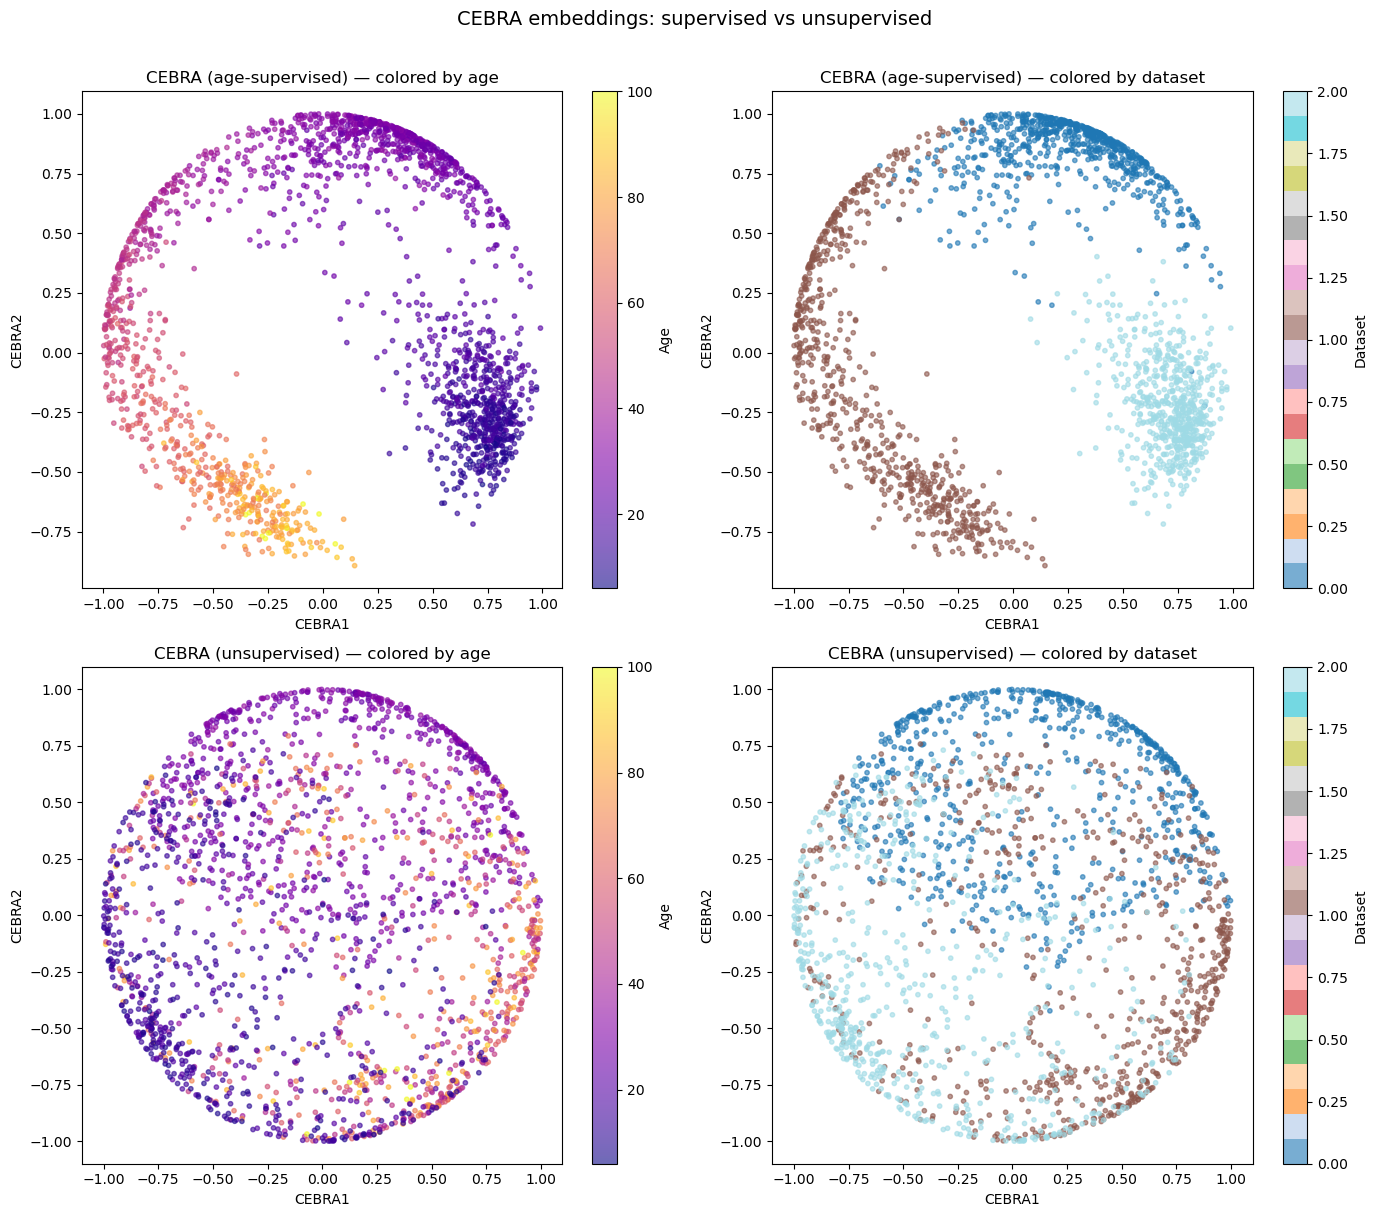

In [ ]:
import cebra
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.model_selection import LeaveOneGroupOut, cross_val_score
import pandas as pd

# ── Setup ──────────────────────────────────────────────────────────────────────
age_mask = huge_df["age"] != -1  #  huge_df["age"].notna() &only rows with age and dataset info
X = sel_pca_result[age_mask].astype(np.float32)        # input: PCA features
ages = huge_df_age[age_mask]["age"].values.astype(np.float32)    # continuous label
groups = huge_df_age[age_mask]["dataset"].values              # for dataset-aware CV

# ── 1. CEBRA with age as the conditioning variable (supervised) ────────────────
cebra_model = cebra.CEBRA(
    model_architecture="offset10-model",
    batch_size=512,
    learning_rate=1e-3,
    temperature=1.0,
    output_dimension=3,          # 3D embedding
    max_iterations=5000,
    verbose=True,
    device="cpu"                 # change to "cuda" if available
)

# Fit conditioned on age — this is the key difference from PCA/UMAP/t-SNE
cebra_model.fit(X, ages)
embedding_age = cebra_model.transform(X)

# ── 2. CEBRA without label (unsupervised) for comparison ──────────────────────
cebra_model_unsup = cebra.CEBRA(
    model_architecture="offset10-model",
    batch_size=512,
    learning_rate=1e-3,
    output_dimension=3,
    max_iterations=5000,
    verbose=True,
    device="cpu"
)
cebra_model_unsup.fit(X)
embedding_unsup = cebra_model_unsup.transform(X)

# ── 3. Visualize: supervised vs unsupervised, colored by age AND dataset ───────
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

dataset_ids = pd.factorize(groups)[0]

plots = [
    (embedding_age,  ages,        "plasma", "CEBRA (age-supervised) — colored by age"),
    (embedding_age,  dataset_ids, "tab20",  "CEBRA (age-supervised) — colored by dataset"),
    (embedding_unsup, ages,       "plasma", "CEBRA (unsupervised) — colored by age"),
    (embedding_unsup, dataset_ids,"tab20",  "CEBRA (unsupervised) — colored by dataset"),
]

for ax, (emb, color, cmap, title) in zip(axes.flat, plots):
    sc = ax.scatter(emb[:, 0], emb[:, 1],
                    c=color, cmap=cmap, s=10, alpha=0.6)
    plt.colorbar(sc, ax=ax, label="Age" if cmap == "plasma" else "Dataset")
    ax.set_title(title)
    ax.set_xlabel("CEBRA1")
    ax.set_ylabel("CEBRA2")

plt.suptitle("CEBRA embeddings: supervised vs unsupervised", y=1.01, fontsize=14)
plt.tight_layout()
plt.show